# Detect computing environment

If using Google Colab, mount the drive and set the base directory to the working folder. If using local, set the base directory.

In [1]:
import os       # Operating system utilities
import sys

# Detect environment
def is_colab():
    """Returns True if running in Google Colab, False otherwise."""
    try:
        import google.colab
        return True
    except ImportError:
        return False

# Set up environment-specific configurations
if is_colab():

    # Colab-specific setup
    !pip install rasterio
    from google.colab import drive
    drive.mount('/content/drive')
    sys.path.append('/content/drive/MyDrive/GitHub/deepSSF/Python')

    # for saving plots etc
    base_path = '/content/drive/MyDrive/GitHub/deepSSF'
    print("Running in Google Colab environment")

else:

    # Local environment setup
    base_path = '..'
    print("Running in local environment")

# Now you can use base_path regardless of environment
print(f"Using base path: {base_path}")


Running in local environment
Using base path: ..


## Import packages

In [2]:
print(sys.version)  # Print Python version in use

import numpy as np                                      # Array operations
import matplotlib.pyplot as plt                         # Plotting library
import torch                                            # Main PyTorch library
import torch.optim as optim                             # Optimization algorithms
import torch.nn as nn                                   # Neural network modules
import os                                               # Operating system utilities
import glob                                             # Pattern matching
import pandas as pd                                     # Data manipulation
import imageio.v2 as imageio                            # Image manipulation - for creating GIFs
from IPython.display import Image, display              # For plotting GIFs
import rasterio                                         # Raster data handling
from datetime import datetime, timedelta                # Date/time utilities
from tqdm import tqdm                                   # Progress bar

from torch.utils.data import Dataset, DataLoader        # Dataset and batch data loading
from datetime import datetime                           # Date/time utilities
from rasterio.plot import show                           # Plot raster data

import deepSSF_model                                    # Import the .py file containing the deepSSF model     
import deepSSF_training_functions                       # Import the .py file containing the training functions
import deepSSF_loss_mixedLR as deepSSF_loss             # Import the .py file containing the deepSSF loss function
import deepSSF_early_stopping                           # Import the .py file containing the early stopping function  
import deepSSF_utils                                    # Import the .py file containing the utility functions 

# Get today's date
today_date = datetime.today().strftime('%Y-%m-%d')

# Set random seed for reproducibility
seed = 42

3.12.9 | packaged by Anaconda, Inc. | (main, Feb  6 2025, 12:55:12) [Clang 14.0.6 ]
Using mps device
Set default tensor type to float32


## Set the device (accelerator - cuda for NVIDIA GPU or mps for Mac)

In [3]:
# Set the device to be used (GPU or CPU)
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device")

if torch.backends.mps.is_available():
    # Set default tensor type for PyTorch
    torch.set_default_dtype(torch.float32)
    print('Set default tensor type to float32')

Using mps device
Set default tensor type to float32


### Create a directory to save the outputs

If we have already run this code today, we will add update index to create a new folder

In [4]:
# Count existing directories with similar pattern
pattern = f'{base_path}/Python/outputs/model_training/djelk_derived_covs_CNN_move_*_{today_date}'
existing_dirs = glob.glob(pattern)
dir_index = len(existing_dirs) + 1

# Create directory with index
output_dir = f'{base_path}/Python/outputs/model_training/djelk_derived_covs_CNN_move_{dir_index}_{today_date}'
os.makedirs(output_dir, exist_ok=True)

print(f"Created directory: {output_dir}")

# To use an existing directory for loading trained model
# output_dir = f'{base_path}/Python/outputs/model_training/id2005_2025-04-01'

Created directory: ../Python/outputs/model_training/djelk_derived_covs_CNN_move_1_2025-06-04


# Import the data and set up the dataset and dataloader

In [5]:
# class buffalo_data(Dataset):
#     def __init__(self, csv_file, transform=None):
#         self.data = pd.read_csv(csv_file)
#         self.npy_base_path = ''

#         # Ensure scalar columns are numeric and convert to tensors directly
#         scalar_columns = [
#             'hour_t1_sin1', 
#             'hour_t1_cos1', 
#             'yday_t1_sin1', 
#             'yday_t1_cos1'
#             ]
        
#         self.data[scalar_columns] = self.data[scalar_columns].apply(pd.to_numeric, errors='coerce').fillna(0)
#         self.scalar_to_grid_data = torch.from_numpy(self.data[scalar_columns].values).float()

#         # Lag the values in column 'A' by one index to get the bearing of the previous step
#         # Pad the missing value with a specified value, e.g., 0
#         self.data['bearing_tm1'] = pd.to_numeric(self.data['bearing'], errors='coerce').shift(1).fillna(0)
#         # Convert to tensor for training
#         self.bearing_tm1 = torch.from_numpy(self.data[['bearing_tm1']].values).float()


#     def __len__(self):
#         return len(self.data)
    

#     def __getitem__(self, index):

#         # Get the paths for the .npy files
#         ndvi_path = os.path.join(self.npy_base_path, self.data.iloc[index]['ndvi_path'])
#         canopy_path = os.path.join(self.npy_base_path, self.data.iloc[index]['canopy_path'])
#         herby_path = os.path.join(self.npy_base_path, self.data.iloc[index]['herby_path'])
#         slope_path = os.path.join(self.npy_base_path, self.data.iloc[index]['slope_path'])

#         # Load the .npy files and convert to tensors
#         # NDVI
#         ndvi_npy = np.load(ndvi_path)
#         ndvi_npy = np.nan_to_num(ndvi_npy, nan=-1.0) # Replace NaNs in the original array with -1, which represents water
#         ndvi_tens = torch.tensor(ndvi_npy, dtype=torch.float32)
#         # Canopy
#         canopy_tens = torch.tensor(np.load(canopy_path), dtype=torch.float32)
#         # Herby
#         herby_tens = torch.tensor(np.load(herby_path), dtype=torch.float32)
#         # Slope
#         slope_npy = np.load(slope_path)
#         slope_npy = np.nan_to_num(slope_npy, nan=0.0) # Replace NaNs in the original array with 0
#         slope_tens = torch.tensor(slope_npy, dtype=torch.float32) 

#         spatial_data_x = torch.stack([ndvi_tens, canopy_tens, herby_tens, slope_tens], dim=0).squeeze()

#         # Load the scalar values and bearing
#         scalar_to_grid_data = self.scalar_to_grid_data[index]
#         bearing_tm1 = self.bearing_tm1[index]

#         # Load the target .tif file
#         target_path = os.path.join(self.npy_base_path, self.data.iloc[index]['target_path'])
#         target = torch.tensor(np.load(target_path), dtype=torch.float32)

#         return spatial_data_x, scalar_to_grid_data, bearing_tm1, target


# With option to preload data to RAM

In [6]:
class buffalo_data(Dataset):
    def __init__(self, csv_file, transform=None, preload=True):
        self.data = pd.read_csv(csv_file)
        self.npy_base_path = ''
        self.preload = preload
        
        # Process scalar columns as before
        scalar_columns = [
            'hour_t1_sin1', 
            'hour_t1_cos1', 
            'yday_t1_sin1', 
            'yday_t1_cos1'
        ]
        
        self.data[scalar_columns] = self.data[scalar_columns].apply(pd.to_numeric, errors='coerce').fillna(0)
        self.scalar_to_grid_data = torch.from_numpy(self.data[scalar_columns].values).float()
        
        # Process bearing as before
        self.data['bearing_tm1'] = pd.to_numeric(self.data['bearing'], errors='coerce').shift(1).fillna(0)
        self.bearing_tm1 = torch.from_numpy(self.data[['bearing_tm1']].values).float()
        
        # Preload all spatial data into memory if requested
        if self.preload:
            self.spatial_data_cache = []
            self.target_cache = []
            
            print("Preloading data into RAM...")
            for idx in tqdm(range(len(self.data))):
                # Get the paths for the .npy files
                ndvi_path = os.path.join(self.npy_base_path, self.data.iloc[idx]['ndvi_path'])
                canopy_path = os.path.join(self.npy_base_path, self.data.iloc[idx]['canopy_path'])
                herby_path = os.path.join(self.npy_base_path, self.data.iloc[idx]['herby_path'])
                slope_path = os.path.join(self.npy_base_path, self.data.iloc[idx]['slope_path'])
                
                # Load the .npy files and convert to tensors
                # NDVI
                ndvi_npy = np.load(ndvi_path)
                ndvi_npy = np.nan_to_num(ndvi_npy, nan=-1.0)
                ndvi_tens = torch.tensor(ndvi_npy, dtype=torch.float32)
                # Canopy
                canopy_tens = torch.tensor(np.load(canopy_path), dtype=torch.float32)
                # Herby
                herby_tens = torch.tensor(np.load(herby_path), dtype=torch.float32)
                # Slope
                slope_npy = np.load(slope_path)
                slope_npy = np.nan_to_num(slope_npy, nan=0.0)
                slope_tens = torch.tensor(slope_npy, dtype=torch.float32)
                
                spatial_data = torch.stack([ndvi_tens, canopy_tens, herby_tens, slope_tens], dim=0).squeeze()
                self.spatial_data_cache.append(spatial_data)
                
                # Load the target .tif file
                target_path = os.path.join(self.npy_base_path, self.data.iloc[idx]['target_path'])
                target = torch.tensor(np.load(target_path), dtype=torch.float32)
                self.target_cache.append(target)
            
            print("Data preloading complete!")

    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, index):
        if self.preload:
            # Use preloaded data
            spatial_data_x = self.spatial_data_cache[index]
            target = self.target_cache[index]
        else:
            # Original disk-loading implementation
            # Get the paths for the .npy files
            ndvi_path = os.path.join(self.npy_base_path, self.data.iloc[index]['ndvi_path'])
            canopy_path = os.path.join(self.npy_base_path, self.data.iloc[index]['canopy_path'])
            herby_path = os.path.join(self.npy_base_path, self.data.iloc[index]['herby_path'])
            slope_path = os.path.join(self.npy_base_path, self.data.iloc[index]['slope_path'])

            # Load the .npy files and convert to tensors
            # NDVI
            ndvi_npy = np.load(ndvi_path)
            ndvi_npy = np.nan_to_num(ndvi_npy, nan=-1.0)
            ndvi_tens = torch.tensor(ndvi_npy, dtype=torch.float32)
            # Canopy
            canopy_tens = torch.tensor(np.load(canopy_path), dtype=torch.float32)
            # Herby
            herby_tens = torch.tensor(np.load(herby_path), dtype=torch.float32)
            # Slope
            slope_npy = np.load(slope_path)
            slope_npy = np.nan_to_num(slope_npy, nan=0.0)
            slope_tens = torch.tensor(slope_npy, dtype=torch.float32) 

            spatial_data_x = torch.stack([ndvi_tens, canopy_tens, herby_tens, slope_tens], dim=0).squeeze()
            
            # Load the target .tif file
            target_path = os.path.join(self.npy_base_path, self.data.iloc[index]['target_path'])
            target = torch.tensor(np.load(target_path), dtype=torch.float32)

        # Load the scalar values and bearing (these are already in memory)
        scalar_to_grid_data = self.scalar_to_grid_data[index]
        bearing_tm1 = self.bearing_tm1[index]

        return spatial_data_x, scalar_to_grid_data, bearing_tm1, target

In [7]:
# Load data into dataset
csv_file = '/Users/scottforrest/deepSSF/buffalo_all_steps_with_paths_n103558_steps.csv'
dataset = buffalo_data(csv_file)

training_split = 0.8
validation_split = 0.1
test_split = 0.1

dataset_train, dataset_val, dataset_test = torch.utils.data.random_split(dataset, [training_split, validation_split, test_split])
print(len(dataset_train))
print(len(dataset_val))
print(len(dataset_test))

Preloading data into RAM...


100%|██████████| 103558/103558 [01:59<00:00, 870.14it/s] 

Data preloading complete!
82847
10356
10355


### Create dataloaders

In [8]:
batch_size = 32 # batch size
num_workers = 0 # number of workers for data loader
dataloader_train = DataLoader(dataset=dataset_train, batch_size=batch_size, shuffle=True, num_workers=num_workers)
dataloader_val = DataLoader(dataset=dataset_val, batch_size=batch_size, shuffle=True, num_workers=num_workers)
dataloader_test = DataLoader(dataset=dataset_test, batch_size=batch_size, shuffle=True, num_workers=num_workers)

Feature x1 batch shape: torch.Size([32, 4, 101, 101])
Feature x2 batch shape: torch.Size([32, 4])
Feature x3 batch shape: torch.Size([32, 1])
Labels batch shape:     torch.Size([32, 101, 101])
tensor([-0.6150,  0.7885,  0.6597,  0.7515])


Text(0.5, 1.0, 'Target location (next step)')

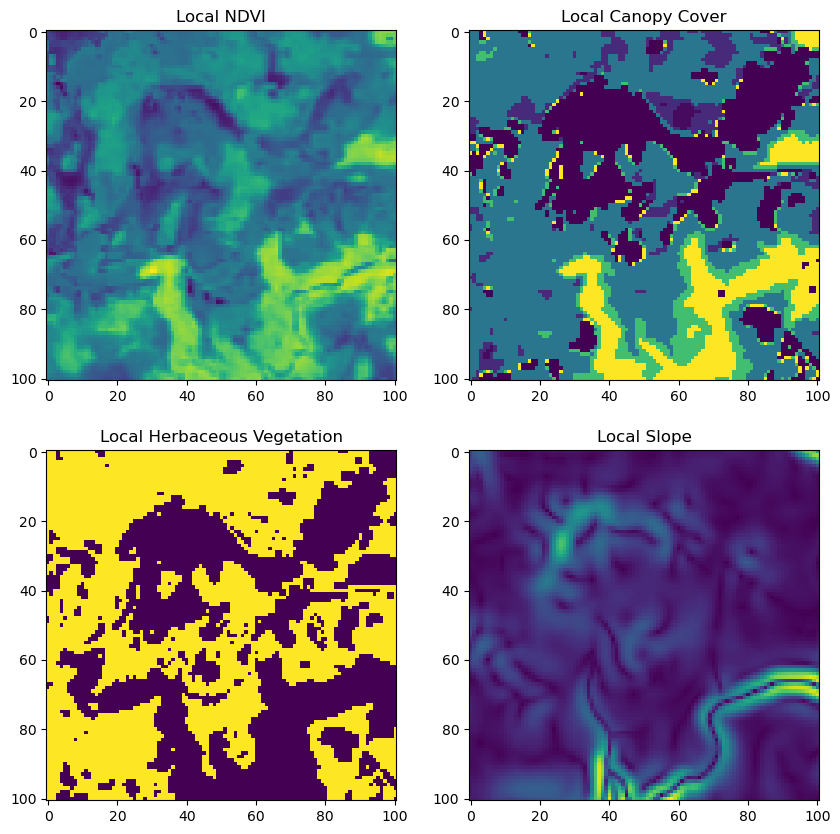

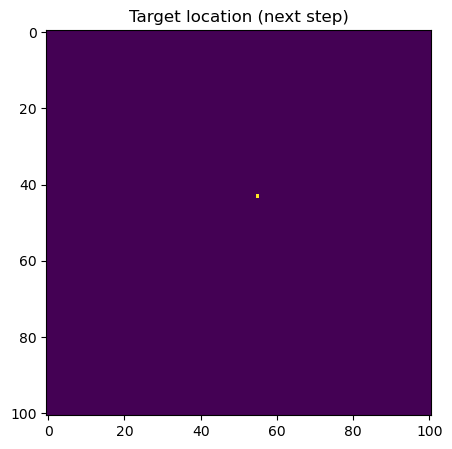

In [9]:
# Display image and label.
x1, x2, x3, labels = next(iter(dataloader_train))
print(f"Feature x1 batch shape: {x1.size()}")
print(f"Feature x2 batch shape: {x2.size()}")
print(f"Feature x3 batch shape: {x3.size()}")
print(f"Labels batch shape:     {labels.size()}")

# print(x3.detach().numpy())
print(x2[0,:])

# Plot the subset
fig, axs = plt.subplots(2, 2, figsize=(10, 10))

# Convert the PyTorch tensor x2 to a NumPy array:
#   1) Detach from the computation graph so no gradients are tracked.
#   2) Move to CPU memory.
#   3) Convert to NumPy.
axs[0, 0].imshow(x1.detach().cpu().numpy()[0,0,:,:], cmap='viridis')
axs[0, 0].set_title('Local NDVI')
axs[0, 1].imshow(x1.detach().cpu().numpy()[0,1,:,:], cmap='viridis')
axs[0, 1].set_title('Local Canopy Cover')
axs[1, 0].imshow(x1.detach().cpu().numpy()[0,2,:,:], cmap='viridis')
axs[1, 0].set_title('Local Herbaceous Vegetation')
axs[1, 1].imshow(x1.detach().cpu().numpy()[0,3,:,:], cmap='viridis')
axs[1, 1].set_title('Local Slope')

# Also plot the target as a single plot
fig, ax = plt.subplots(figsize=(5, 5))
im = ax.imshow(labels.detach().numpy()[0,:,:], cmap='viridis')
ax.set_title('Target location (next step)')

# Load the model

As we have already described the model in detail in the `deepSSF_model` script, we can simply import the model here.

We will use the same model architecture as in the previous script, except that we will need to use a slightly edited dictionary to account for the additional input channels.

## Define the parameters for the model

Here we enter the specific parameter values and hyperparameters for the model. 
These are the values that will be used to instantiate the model.

In [10]:
n_max_pool_layers = 2 # used to determine the number of inputs entering the fully connected block - needs to be manually changed if the number of max pooling layers is changed
n_scalar_inputs = 4 # number of scalar inputs that are converted to a grid and appended to the spatial features

params_dict = {"batch_size": batch_size, #number of samples in each batch
               "image_dim": 101, #number of pixels along the edge of each local patch/image
               "pixel_size": 25, #number of metres along the edge of a pixel
               "input_channels": 4 + n_scalar_inputs, #number of spatial layers in each image + number of scalar layers that are converted to a grid
               "dim_in_nonspatial_to_grid": n_scalar_inputs, #the number of scalar predictors that are converted to a grid and appended to the spatial features
               "dense_dim_in_nonspatial": n_scalar_inputs, #change this to however many other scalar predictors you have (bearing, velocity etc)
               "kernel_size": 3, #the size of the 2D moving windows / kernels that are being learned
               "stride": 1, #the stride used when applying the kernel.  This reduces the dimension of the output if set to greater than 1
               "kernel_size_mp": 2, #the size of the kernel that is used in max pooling operations
               "stride_mp": 2, #the stride that is used in max pooling operations
               "padding": 1, #the amount of padding to apply to images prior to applying the 2D convolution
               "num_movement_params": 12, #number of parameters used to parameterise the movement kernel
               "dropout": 0.1, #the proportion of nodes that are dropped out in the dropout layers

               # hyperparameters that change the model architecture
               "output_channels": 4, #number of convolution filters to learn
               "output_channels_movement": 4, #number of convolution filters to learn for the movement kernel
               "dense_dim_hidden": 128, #number of nodes in the hidden layers

               # this will be updated below
               "dense_dim_in_all": n_scalar_inputs, #number of inputs entering the fully connected block once the nonspatial features have been concatenated to the spatial features
               "device": device
               }

# Now update the dictionary with calculated values
params_dict["dense_dim_in_all"] = int(((params_dict["image_dim"] - (params_dict["image_dim"] % 2))**2) * (params_dict["output_channels_movement"] / (4**n_max_pool_layers)))

## Instantiate the model

As described in the `deepSSF_train.ipynb` script, we saved the model definition into a file named `deepSSF_model.py`. We can instantiate the model by importing the file (which was done when importing other packages) and calling the classes parameter dictionary from that script.

In [11]:
params = deepSSF_model.ModelParams(params_dict)
model = deepSSF_model.ConvJointModel(params).to(device)
print(model)

ConvJointModel(
  (scalar_grid_output): Scalar_to_Grid_Block()
  (conv_habitat): Conv2d_block_spatial(
    (conv2d): Sequential(
      (0): Conv2d(8, 4, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU()
      (2): Conv2d(4, 4, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU()
      (4): Conv2d(4, 4, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (5): ReLU()
      (6): Conv2d(4, 1, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    )
  )
  (conv_movement): Conv2d_block_toFC(
    (conv2d): Sequential(
      (0): Conv2d(8, 4, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU()
      (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (3): Conv2d(4, 4, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): ReLU()
      (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (6): Flatten(start_dim=1, end_dim=-1)
    )
  )
  (fcn_movement_all): FCN_block

# Pull out some testing data

To test the other blocks, and the full model, we will need some data. We can pull that out from the training set.

In [12]:
# Number of samples in the train dataset
print("Number of samples in the train dataset: ", len(dataloader_train.dataset))
print('\n')

# Select an index from the test dataset to retrieve a sample, between 0 and number of samples
# We picked this fairly arbitrarily, but with some interesting environmental features to illustrate the model's predictions
iteration_index = 2700

# iteration_index = 1010
# iteration_index = 3971

# print(buffalo_df.iloc[iteration_index])

# return spatial_data_x, scalar_to_grid_data, bearing_tm1, target

# 2. Retrieve a single sample (features and label) from the test dataset at the specified index

# sample_spatial_covs is a sample of the spatial covariates for a single step
# sample_temporal_covs is a sample of the temporal covariates for a single step
# sample_prev_bearing is a sample bearing of the previous step
# sample_next_step is the target label (what we are trying to predict) for the next step

# We set these here and will also use them later in the script to check how the model's predictions look,
# and when we extract feature maps from the convolutional layers
sample_spatial_covs, sample_temporal_covs, sample_prev_bearing, sample_next_step = dataloader_train.dataset[iteration_index]

# 3. Reshape data tensors to add a batch dimension (since the model expects batches)
sample_spatial_covs = sample_spatial_covs.unsqueeze(0).to(device)
sample_temporal_covs = sample_temporal_covs.unsqueeze(0).to(device)
sample_prev_bearing = sample_prev_bearing.unsqueeze(0).to(device)
sample_next_step = sample_next_step.unsqueeze(0).to(device)

print(f'Shape of the sample spatial covariates:  {sample_spatial_covs.shape}')
print(f'Shape of the sample temporal covariates: {sample_temporal_covs.shape}')
print(f'Shape of the sample previous bearing:    {sample_prev_bearing.shape}')
print(f'Shape of the sample next step:           {sample_next_step.shape}')

Number of samples in the train dataset:  82847


Shape of the sample spatial covariates:  torch.Size([1, 4, 101, 101])
Shape of the sample temporal covariates: torch.Size([1, 4])
Shape of the sample previous bearing:    torch.Size([1, 1])
Shape of the sample next step:           torch.Size([1, 101, 101])


Text(0.5, 1.0, 'Target location (next step)')

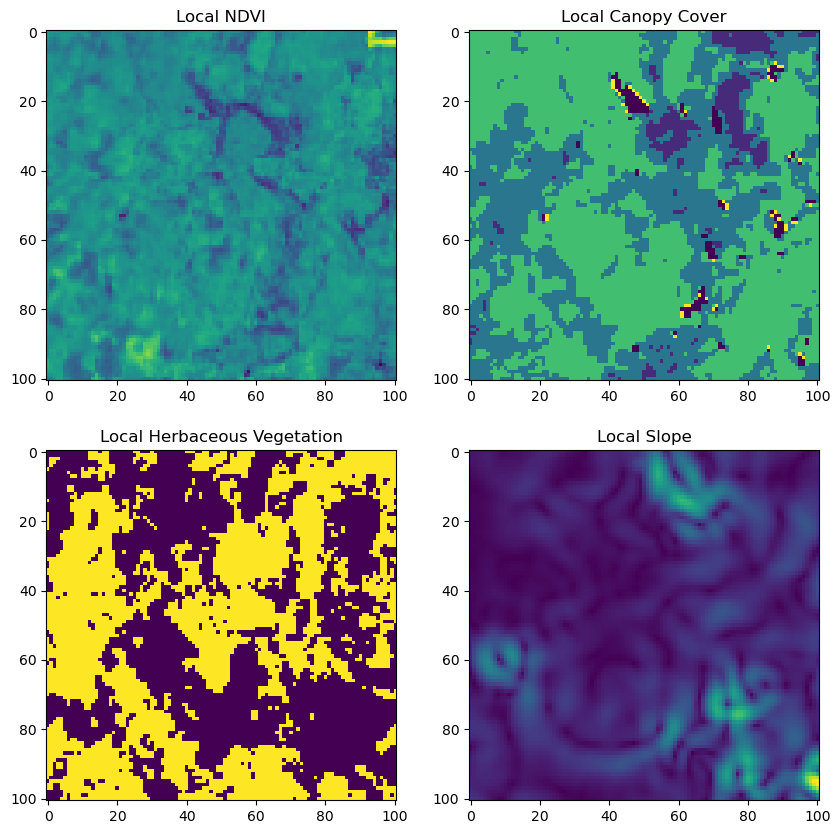

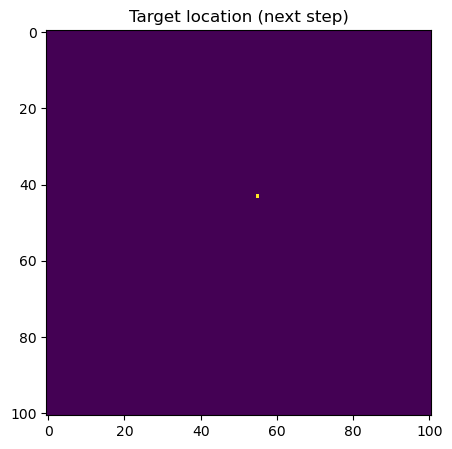

In [13]:
# Plot the subset
fig, axs = plt.subplots(2, 2, figsize=(10, 10))

axs[0, 0].imshow(sample_spatial_covs.detach().cpu().numpy()[0,0,:,:], cmap='viridis')
axs[0, 0].set_title('Local NDVI')
axs[0, 1].imshow(sample_spatial_covs.detach().cpu().numpy()[0,1,:,:], cmap='viridis')
axs[0, 1].set_title('Local Canopy Cover')
axs[1, 0].imshow(sample_spatial_covs.detach().cpu().numpy()[0,2,:,:], cmap='viridis')
axs[1, 0].set_title('Local Herbaceous Vegetation')
axs[1, 1].imshow(sample_spatial_covs.detach().cpu().numpy()[0,3,:,:], cmap='viridis')
axs[1, 1].set_title('Local Slope')

# Also plot the target as a single plot
fig, ax = plt.subplots(figsize=(5, 5))
im = ax.imshow(labels.detach().numpy()[0,:,:], cmap='viridis')
ax.set_title('Target location (next step)')

### Pull out the scalar values

In [14]:
# Extract the first sample (index 0) and its respective channel for each variable:
hour_t2_sin = sample_temporal_covs.detach().cpu().numpy()[0, 0]
hour_t2_cos = sample_temporal_covs.detach().cpu().numpy()[0, 1]
yday_t2_sin = sample_temporal_covs.detach().cpu().numpy()[0, 2]
yday_t2_cos = sample_temporal_covs.detach().cpu().numpy()[0, 3]

# Convert x3 similarly and extract the bearing from the first sample and channel:
bearing = sample_prev_bearing.detach().cpu().numpy()[0, 0]

hour_t2 = deepSSF_utils.recover_hour(hour_t2_sin, hour_t2_cos)
hour_t2_integer = int(hour_t2)  # Convert to integer
print(f'Hour:               {hour_t2_integer}')

yday_t2 = deepSSF_utils.recover_yday(yday_t2_sin, yday_t2_cos)
yday_t2_integer = int(yday_t2)  # Convert to integer
print(f'Day of the year:    {yday_t2_integer}')

bearing_degrees = np.degrees(bearing) % 360
bearing_degrees = round(bearing_degrees, 1)  # Round to 2 decimal places
bearing_degrees = int(bearing_degrees)  # Convert to integer
print(f'Bearing (radians):  {bearing}')
print(f'Bearing (degrees):  {bearing_degrees}')

Hour:               16
Day of the year:    150
Bearing (radians):  -1.1592904329299927
Bearing (degrees):  293


## Set model hyperparameters

Set the learning rate, loss function, optimizer, scheduler and early stopping. 

In [15]:
# learning_rate = 1e-3

# # Define the negative log-likelihood loss function with mean reduction
# loss_fn = deepSSF_loss.negativeLogLikeLoss(reduction='mean')

# # path to save the model weights
# path_save_weights = f'model_checkpoints/deepSSF_derived-covs_single_input_buffalo_{today_date}.pt'

# # Set up the Adam optimizer for updating the model's parameters
# optimiser = optim.Adam(model.parameters(), lr=learning_rate)

# # Create a learning rate scheduler that reduces the LR by a factor of 0.1 
# #    if validation loss has not improved for 'patience=5' epochs
# scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
#     optimiser,  # The optimizer whose learning rate will be adjusted
#     mode='min', # The metric to be minimized (e.g., validation loss)
#     factor=0.1, # Factor by which the learning rate will be reduced
#     patience=5  # Number of epochs with no improvement before learning rate reduces
# )

# # EarlyStopping stops training after 'patience=10' epochs with no improvement, 
# #    optionally saving the best model weights
# early_stopping = deepSSF_early_stopping.EarlyStopping(patience=20, verbose=True, path=path_save_weights)

## Training loop

This code defines the main training loop for a single epoch. It iterates over batches from the training dataloader, moves the data to the correct device (e.g., CPU or GPU), calculates the loss, and performs backpropagation to update the model parameters. It also prints periodic updates of the current loss.

In [16]:
train_loop = deepSSF_training_functions.train_loop
test_loop = deepSSF_training_functions.test_loop

## Loss function

In [17]:
loss_fn = deepSSF_loss.negativeLogLikeLoss(reduction='mean')

## Early stopping

In [18]:
early_stopping = deepSSF_early_stopping.EarlyStopping

# Train the model

Here we have the main training process that loops over multiple epochs. Each epoch involves:

1. Training the model on a training dataset.
2. Validating the model on a validation dataset to monitor its performance and adjust the learning rate (via scheduler).
3. Checking for early stopping conditions. If triggered, the best model weights are restored, and a test evaluation is performed.

Additionally, commented-out code at the end shows how you might visualise and save intermediate training results (such as predicted probability surfaces) for diagnostic or research purposes. The saved images can then be combined into an animation.

Output directory: ../Python/outputs/model_training/djelk_derived_covs_CNN_move_1_2025-06-04
../Python/outputs/model_training/djelk_derived_covs_CNN_move_1_2025-06-04/checkpoint_deepSSF_model.pt
ConvJointModel(
  (scalar_grid_output): Scalar_to_Grid_Block()
  (conv_habitat): Conv2d_block_spatial(
    (conv2d): Sequential(
      (0): Conv2d(8, 4, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU()
      (2): Conv2d(4, 4, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU()
      (4): Conv2d(4, 4, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (5): ReLU()
      (6): Conv2d(4, 1, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    )
  )
  (conv_movement): Conv2d_block_toFC(
    (conv2d): Sequential(
      (0): Conv2d(8, 4, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU()
      (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (3): Conv2d(4, 4, kernel_size=(3, 3), stride=(1, 1), padding=(1,

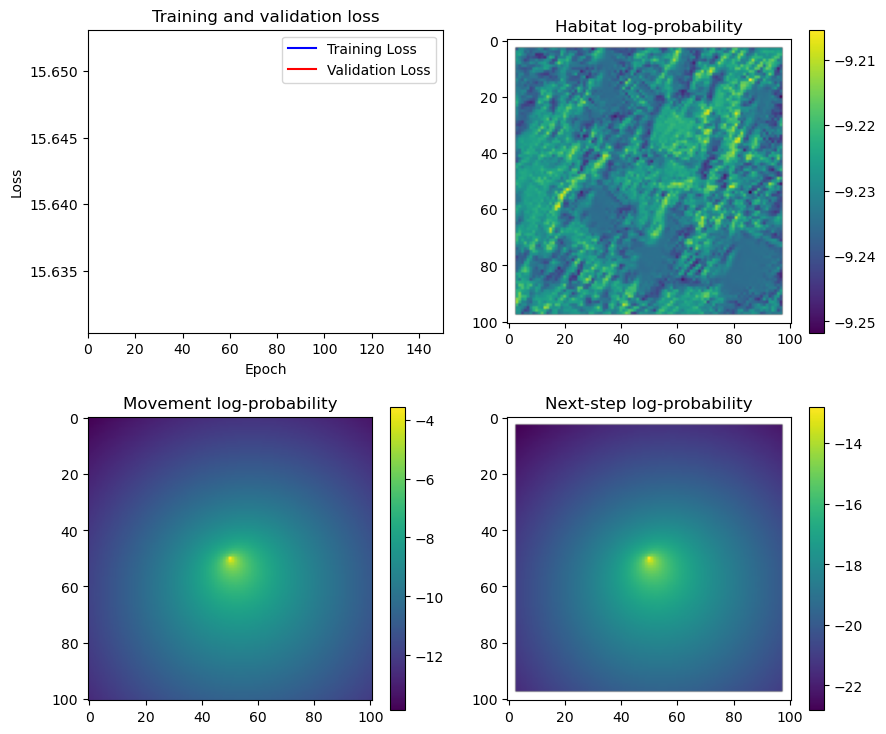

Epoch 2
-------------------------------
loss:       16.123764  [   32/82847]
loss:       15.492105  [ 1632/82847]
loss:       15.488626  [ 3232/82847]
loss:       15.087811  [ 4832/82847]
loss:       15.385881  [ 6432/82847]
loss:       15.101732  [ 8032/82847]
loss:       14.956161  [ 9632/82847]
loss:       16.574959  [11232/82847]
loss:       15.241556  [12832/82847]
loss:       14.635101  [14432/82847]
loss:       15.602457  [16032/82847]
loss:       15.525827  [17632/82847]
loss:       15.694309  [19232/82847]
loss:       15.153398  [20832/82847]
loss:       14.414225  [22432/82847]
loss:       15.106556  [24032/82847]


KeyboardInterrupt: 

In [19]:
print(f'Output directory: {output_dir}')
path_save_weights = f'{output_dir}/checkpoint_deepSSF_model.pt'
print(path_save_weights)

epochs = 150
train_losses = []  # Track training losses across epochs
val_losses = []   # Track validation losses across epochs
val_habitat_losses = []  # Track validation habitat losses across epochs
val_movement_losses = []  # Track validation movement losses across epochs
# Difference in loss between epochs
train_diff = []
val_diff = []
val_habitat_diff = []
val_movement_diff = []

# Initialize the parameter container using the parameters defined in 'params_dict'
params = deepSSF_model.ModelParams(params_dict)
# Create an instance of the ConvJointModel using the parameters,
# and move the model to the specified device (e.g., CPU or GPU)
model = deepSSF_model.ConvJointModel(params).to(device)
# Print the model architecture
print(model)

# Define the negative log-likelihood loss function with mean reduction
loss_fn = deepSSF_loss.negativeLogLikeLoss(reduction='mean') #, alpha=0.5

# Set the initial learning rates for each process
initial_learning_rate_movement = 1e-5
initial_learning_rate_habitat = 1e-4

# Create a combined optimiser for all movement-related parameters
movement_params = list(model.conv_movement.parameters()) + list(model.fcn_movement_all.parameters())
# movement_params = model.fcn_movement_all.parameters()

# Define separate optimizers for each component
optimiser_movement = optim.Adam(movement_params, lr=initial_learning_rate_movement)
optimiser_habitat = optim.Adam(model.conv_habitat.parameters(), lr=initial_learning_rate_habitat)

# Put optimisers into a tuple to call in the training loop
optimisers = (optimiser_movement, optimiser_habitat)

# Create separate schedulers for each optimizer
scheduler_movement = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimiser_movement, 'min', factor=0.1, patience=5)
scheduler_habitat = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimiser_habitat, 'min', factor=0.1, patience=5)

# Initialise early stopping 
early_stopping = deepSSF_early_stopping.EarlyStopping(patience=15, verbose=True, path=path_save_weights)

# Create directory for saving training images
os.makedirs(f'{output_dir}/training_images', exist_ok=True)
os.makedirs(f'{output_dir}/loss_images', exist_ok=True)

for t in range(epochs):

    # Initialise variables to store during training
    train_loss = 0.0
    num_train_batches = len(dataloader_train)

    val_loss = 0.0
    val_loss_habitat = 0.0
    val_loss_movement = 0.0
    num_batches = len(dataloader_val)

    print(f"Epoch {t+1}\n-------------------------------")

    # Skip training in the first epoch, but still calculate losses
    skip_training = (t == 0)

    # 1. Run the training loop for one epoch using the training dataloader
    epoch_loss = train_loop(dataloader_train, model, loss_fn, optimisers, 
                            skip_epoch0_training=skip_training,
                            batch_size=32)
    
    train_losses.append(epoch_loss.item())

    # 2. Evaluate model performance on the validation dataset
    model.eval()  # Switch to evaluation mode for proper layer behavior
    with torch.no_grad():

        # Loop through each batch in the validation dataloader
        for x1, x2, x3, y in dataloader_val:
            # Move data to the chosen device (CPU/GPU)
            x1 = x1.to(device)
            x2 = x2.to(device)
            x3 = x3.to(device)
            y = y.to(device)

            # Accumulate validation loss
            total_loss, habitat_loss, movement_loss = loss_fn(model((x1, x2, x3)), y)
            val_loss += total_loss.detach()
            val_loss_habitat += habitat_loss.detach()
            val_loss_movement += movement_loss.detach()

    # # 3. Step the scheduler based on the validation loss (adjusts learning rate if needed)
    # scheduler.step(val_loss)

    # Step the movement scheduler
    scheduler_movement.step(val_loss_movement)

    # Step the habitat scheduler regardless of the movement weight
    scheduler_habitat.step(val_loss_habitat)

    # 4. Compute the average validation loss and print it, along with the current learning rate
    val_loss /= num_batches
    val_loss_habitat /= num_batches
    val_loss_movement /= num_batches

    print(f"Avg validation loss:            {val_loss:>15f}")
    print(f"Avg validation habitat loss:    {val_loss_habitat:>15f}")
    print(f"Avg validation movement loss:   {val_loss_movement:>15f}")
    print(f"Movement learning rate:         {scheduler_movement.get_last_lr()}")
    print(f"Habitat learning rate:          {scheduler_habitat.get_last_lr()}")

    # 5. Track the validation loss for plotting or monitoring
    val_losses.append(val_loss.item())
    val_habitat_losses.append(val_loss_habitat.item())
    val_movement_losses.append(val_loss_movement.item())

    # Memory management - add after validation but before early stopping check
    # torch.mps.empty_cache()
    # gc.collect()

    # 6. Early stopping: if no improvement in validation loss for a set patience, stop training
    early_stopping(val_loss, model)
    if early_stopping.early_stop:
        print("Early stopping")
        # Restore the best model weights saved by EarlyStopping
        model.load_state_dict(torch.load(path_save_weights, weights_only=True, map_location=device))
        test_loop(dataloader_test, model, loss_fn)  # Evaluate on test set once training stops
        break
    else:
        model.eval()
        print("\n")

    torch.cuda.empty_cache()


    # ----------------------------------------------------
    # The following code demonstrates how
    # to optionally visualize or save intermediate results
    # (e.g., habitat probability surface, movement probability,
    # and next-step probability surfaces).

    # uncomment the code all in one go to run it (it should be inside the training loop)
    # ----------------------------------------------------

    # Extract training and validation losses for plotting

    # Convert the list of tensors to a single tensor
    train_losses_np = torch.tensor(train_losses).detach().cpu().numpy()
    val_losses_np = torch.tensor(val_losses).detach().cpu().numpy()
    val_habitat_losses_np = torch.tensor(val_habitat_losses).detach().cpu().numpy()
    val_movement_losses_np = torch.tensor(val_movement_losses).detach().cpu().numpy()

    # Get the difference in losses between epochs
    train_diff.append(train_losses_np[t] - train_losses_np[t-1])
    val_diff.append(val_losses_np[t] - val_losses_np[t-1])
    val_habitat_diff.append(val_habitat_losses_np[t] - val_habitat_losses_np[t-1])
    val_movement_diff.append(val_movement_losses_np[t] - val_movement_losses_np[t-1])

    # Number of epochs
    n_epochs = len(val_losses)

    # -----------------------------------------------------------
    # 1. Retrieve a single test example (covariates and labels)
    #    at the specified 'iteration_index' from the test dataset
    # -----------------------------------------------------------
    x1, x2, x3, labels = dataloader_train.dataset[iteration_index]

    # -----------------------------------------------------------
    # 2. Add a batch dimension and move tensors to the device
    #    for model inference
    # -----------------------------------------------------------
    x1 = x1.unsqueeze(0).to(device)
    x2 = x2.unsqueeze(0).to(device)
    x3 = x3.unsqueeze(0).to(device)

    # -----------------------------------------------------------
    # 3. Run the model on the single test example
    # -----------------------------------------------------------
    test = model((x1, x2, x3))

    # -----------------------------------------------------------
    # 4. Extract habitat and movement outputs;
    #    convert them to NumPy arrays for visualization
    # -----------------------------------------------------------
    hab_density = test.detach().cpu().numpy()[0, :, :, 0]
    movement_density = test.detach().cpu().numpy()[0, :, :, 1]

    # -----------------------------------------------------------
    # 5. Generate masks to exclude certain border cells for
    #    color scale reasons (setting them to -inf).
    # -----------------------------------------------------------
    x_mask = np.ones_like(hab_density)
    y_mask = np.ones_like(hab_density)

    # Mask out a few columns (0-2 and 98-end) and rows (0-2 and 98-end)
    x_mask[:, :3] = -np.inf
    x_mask[:, 98:] = -np.inf
    y_mask[:3, :] = -np.inf
    y_mask[98:, :] = -np.inf

    # Apply the masks to habitat density
    hab_density_mask = hab_density * x_mask * y_mask

    # Combine habitat and movement densities to represent
    # next-step probability
    step_density = hab_density + movement_density
    step_density_mask = step_density * x_mask * y_mask

    # Plot the covariates
    fig, axs = plt.subplots(2, 2, figsize=(9, 7.5))

    # # Plot NDVI
    # im1 = axs[0, 0].imshow(ndvi_natural.numpy(), cmap='viridis')
    # axs[0, 0].set_title('NDVI')
    # fig.colorbar(im1, ax=axs[0, 0])

    # Plot Training and Validation Loss
    axs[0, 0].plot(range(n_epochs), train_losses_np, label='Training Loss', color='blue')
    axs[0, 0].plot(range(n_epochs), val_losses_np, label='Validation Loss', color='red')
    # axs[0, 0].plot(range(n_epochs), val_habitat_losses_np, label='Validation Habitat Loss', color='green')
    # axs[0, 0].plot(range(n_epochs), val_movement_losses_np, label='Validation Movement Loss', color='orange')
    axs[0, 0].set_xlim(0, epochs)
    axs[0, 0].set_title('Training and validation loss')
    axs[0, 0].set_xlabel('Epoch')
    axs[0, 0].set_ylabel('Loss')
    axs[0, 0].legend()

    # Plot habitat selection log-probability
    im2 = axs[0, 1].imshow(hab_density_mask, cmap='viridis')
    axs[0, 1].set_title('Habitat log-probability')
    fig.colorbar(im2, ax=axs[0, 1])

    # Plot movement log-probability
    im3 = axs[1, 0].imshow(movement_density, cmap='viridis')
    axs[1, 0].set_title('Movement log-probability')
    fig.colorbar(im3, ax=axs[1, 0])

    # Plot next-step log-probability
    im4 = axs[1, 1].imshow(step_density_mask, cmap='viridis')
    axs[1, 1].set_title('Next-step log-probability')
    fig.colorbar(im4, ax=axs[1, 1])

    filename_covs = f'{output_dir}/training_images/training_epoch_index{t}_yday{yday_t2_integer}_hour{hour_t2_integer}_bearing{bearing_degrees}.png'
    plt.tight_layout()
    plt.savefig(filename_covs, dpi=300) # creates inconsistent image sizes >>> , bbox_inches='tight'
    # plt.show()
    plt.close()  # Close the figure to free memory

    # Plot the difference in the loss of each component between epochs
    filename_diff = f'{output_dir}/loss_images/training_diff_epoch_index{t}_yday{yday_t2_integer}_hour{hour_t2_integer}_bearing{bearing_degrees}.png'
    plt.axhline(y=0, color='black', linestyle='--', label='Null Probability')  # null probs
    # plt.plot(range(n_epochs), train_diff, label='Training Loss Difference', color='blue')
    # plt.plot(range(n_epochs), val_diff, label='Validation Loss Difference', color='red')
    plt.plot(range(n_epochs), val_habitat_diff, label='Validation Habitat Loss Difference', color='green')
    plt.plot(range(n_epochs), val_movement_diff, label='Validation Movement Loss Difference', color='orange')
    plt.xlim(0, epochs)
    plt.title('Habitat and movement loss difference')
    plt.xlabel('Epoch')
    plt.ylabel('Loss difference')
    plt.legend()
    # plt.tight_layout()
    plt.savefig(filename_diff, dpi=300) # creates inconsistent image sizes >>> , bbox_inches='tight'
    # plt.show()
    plt.close()  # Close the figure to free memory

print("Done!")

### Make a GIF of the training images

First, here's a function to call to make a gif from a given directory.

In [20]:
# Example sorting by the epoch number
def extract_index(filename):
    # Extract the epoch number from the filename
    # Adjust the extraction based on your naming pattern
    import re
    match = re.search(r'index(\d+)_', filename)
    if match:
        return int(match.group(1))
    return 0

def create_gif(image_folder, output_filename, fps=10):
    """
    Creates a GIF from a sequence of images in a folder.

    Parameters:
    - image_folder: Path to the folder containing images
    - output_filename: Name of the output GIF file
    - duration: Duration of each frame in seconds
    """
    # Get all png files in the specified folder, sorted by name
    images = sorted(glob.glob(os.path.join(image_folder, '*.png')), key=extract_index)

    # Check if any images were found
    if not images:
        print(f"No images found in {image_folder}")
        return

    # Read all images
    frames = [imageio.imread(image) for image in images]

    # Save as GIF
    imageio.mimsave(output_filename, frames, fps=fps, loop=0)

    display(Image(filename=output_filename))

    print(f"GIF created successfully: {output_filename}")


## Create training GIF

In [21]:
# Path to your images
image_folder =  f'{output_dir}/training_images'
# Output GIF filename
output_filename = f'{output_dir}/training_gif_yday{yday_t2_integer}_hour{hour_t2_integer}_bearing{bearing_degrees}.gif'
# Create the GIF
create_gif(image_folder, output_filename, fps=10)

No images found in ../Python/outputs/model_training/djelk_derived_covs_CNN_move_1_2025-06-04/training_images


## Create loss GIF

In [22]:
# Path to your images
image_folder =  f'{output_dir}/loss_images'
# Output GIF filename
output_filename = f'{output_dir}/loss_gif.gif'
# Create the GIF
create_gif(image_folder, output_filename, fps=10)

No images found in ../Python/outputs/model_training/djelk_derived_covs_CNN_move_1_2025-06-04/loss_images


In [23]:
# to look at the parameters (weights and biases) of the model
# print(model.state_dict())

# Loading in previous models

As we've trained the model, the model parameters are already stored in the `model` object. But as we were training the model, we were saving it to file, and that, and other trained models can be loaded.

The model parameters that are being loaded must match the model object that has been defined above. If the model object has changed, the model parameters will not be able to be loaded.

In [24]:
path_save_weights

'../Python/outputs/model_training/djelk_derived_covs_CNN_move_1_2025-06-04/checkpoint_deepSSF_model.pt'

### If loading a previously trained model

In [25]:
# to load previously saved weights
# path_save_weights = f'{output_dir}/checkpoint_deepSSF_buffalo2005_2025-04-01.pt'

model.load_state_dict(torch.load(path_save_weights,
                                 weights_only=True,
                                 map_location=torch.device('cpu')))

FileNotFoundError: [Errno 2] No such file or directory: '../Python/outputs/model_training/djelk_derived_covs_CNN_move_1_2025-06-04/checkpoint_deepSSF_model.pt'

# View model outputs

## Create a directory to save model outputs

### Save the validation loss as a dataframe

In [ ]:
# Directory for saving the loss dataframe
filename_loss_csv = f'{output_dir}/deepSSF_val_loss.csv'

# Check if val_losses is defined (which means a model has been trained in this session)
try:

    # Convert the list of tensors to a single tensor
    val_losses_tensor = torch.tensor(val_losses)

    print("val_losses has been defined - storing as csv\n")

    # Number of epochs
    n_epochs = len(val_losses)
    print(f'Number of epochs: {n_epochs}')

    val_losses_df = pd.DataFrame({
        "epoch": range(1, n_epochs + 1),
        "val_losses": val_losses_tensor.detach().cpu().numpy()
    })

    print(val_losses_df.head())

    # Save the validation losses to a CSV file
    val_losses_df.to_csv(filename_loss_csv, index=False)

# if val_losses hasn't been defined (for if you are loading model weights from a saved object)
except NameError:

    # This code runs if val_losses is not defined
    print("val_losses has not been defined - loading from saved csv\n")
    # Initialize it with a default value

    # Read the val_losses csv file
    val_losses_df = pd.read_csv(filename_loss_csv)
    print(val_losses_df.head())

    # Number of epochs
    n_epochs = len(val_losses_df)
    print(f'\nNumber of epochs: {n_epochs}')


val_losses has been defined - storing as csv

Number of epochs: 150
   epoch  val_losses
0      1   15.564251
1      2   14.840216
2      3   14.797134
3      4   14.771282
4      5   14.746819


In [ ]:
# Directory for saving the loss dataframe
filename_train_loss_csv = f'{output_dir}/deepSSF_train_loss.csv'

# Check if train_losses is defined (which means a model has been trained in this session)
try:

    # Convert the list of tensors to a single tensor
    train_losses_tensor = torch.tensor(train_losses)

    print("train_losses has been defined - storing as csv\n")

    train_losses_df = pd.DataFrame({
        "epoch": np.linspace(1, n_epochs, len(train_losses)),
        "train_losses": train_losses_tensor.detach().cpu().numpy()
    })

    print(train_losses_df.head)

    # Save the train losses to a CSV file
    train_losses_df.to_csv(filename_train_loss_csv, index=False)

# if train_losses hasn't been defined (for if you are loading model weights from a saved object)
except NameError:

    # This code runs if train_losses is not defined
    print("train_losses has not been defined - loading from saved csv\n")
    # Initialize it with a default value

    # Read the train_losses csv file
    train_losses_df = pd.read_csv(filename_train_loss_csv)
    print(train_losses_df.head())


train_losses has been defined - storing as csv

<bound method NDFrame.head of      epoch  train_losses
0      1.0     15.551800
1      2.0     14.931127
2      3.0     14.811133
3      4.0     14.779747
4      5.0     14.751720
..     ...           ...
145  146.0     14.454071
146  147.0     14.453863
147  148.0     14.453954
148  149.0     14.453691
149  150.0     14.454311

[150 rows x 2 columns]>


### Plot the validation loss

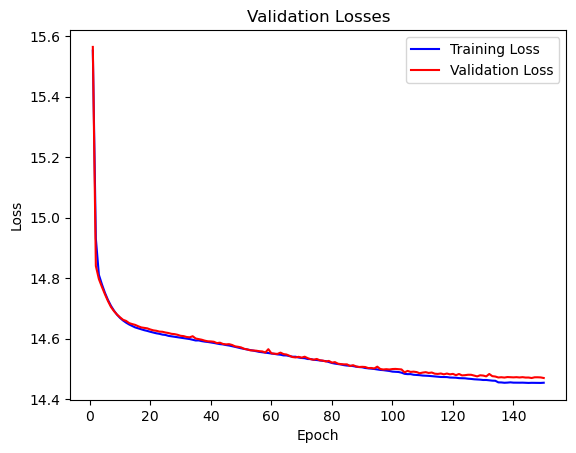

In [ ]:
# Directory for saving the loss plots
filename_loss = f'{output_dir}/val_loss.png'

# Plot the validation losses
plt.plot(train_losses_df['epoch'], train_losses_df['train_losses'], label='Training Loss', color='blue')  # Plot training loss in blue
plt.plot(val_losses_df['epoch'], val_losses_df['val_losses'], label='Validation Loss', color='red')  # Plot validation loss in red
plt.title('Validation Losses')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()  # Show legend to distinguish lines
plt.savefig(filename_loss, dpi=300, bbox_inches='tight')
plt.show()

# Test the model on sample covariates

Use the same sample covariates as above (selected before training the model) from the *test* dataset, and then run the model on these covariates. To select a different sample, change the `iteration_index` in the code above and re-run those chunks.

Print the scalar values and plot the sample covariates

Hour:               10
Day of the year:    19
Bearing (radians):  -2.569408655166626
Bearing (degrees):  212


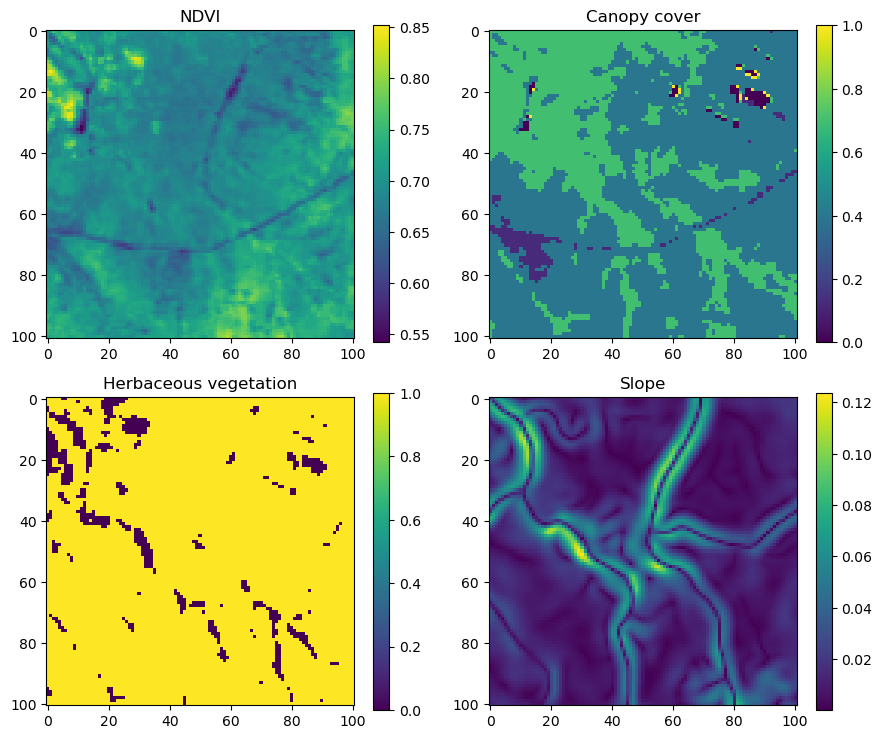

In [ ]:
# Print relevant information about the current prediction context
# such as time of day, day of year, and bearing angles in both radians and degrees.
print(f'Hour:               {hour_t2_integer}')
print(f'Day of the year:    {yday_t2_integer}')
print(f'Bearing (radians):  {bearing}')
print(f'Bearing (degrees):  {bearing_degrees}')

# Plot the covariates
fig, axs = plt.subplots(2, 2, figsize=(9, 7.5))

# Plot NDVI
im1 = axs[0, 0].imshow(sample_spatial_covs.detach().cpu().numpy()[0,0,:,:], cmap='viridis')
axs[0, 0].set_title('NDVI')
fig.colorbar(im1, ax=axs[0, 0])

# Plot Canopy cover
im2 = axs[0, 1].imshow(sample_spatial_covs.detach().cpu().numpy()[0,1,:,:], cmap='viridis')
axs[0, 1].set_title('Canopy cover')
fig.colorbar(im2, ax=axs[0, 1])

# Plot Herbaceous vegetation
im3 = axs[1, 0].imshow(sample_spatial_covs.detach().cpu().numpy()[0,2,:,:], cmap='viridis')
axs[1, 0].set_title('Herbaceous vegetation')
fig.colorbar(im3, ax=axs[1, 0])

# Plot Slope
im4 = axs[1, 1].imshow(sample_spatial_covs.detach().cpu().numpy()[0,3,:,:], cmap='viridis')
axs[1, 1].set_title('Slope')
fig.colorbar(im4, ax=axs[1, 1])

filename_covs = f'{output_dir}/sample{iteration_index}_yday{yday_t2_integer}_hour{hour_t2_integer}_bearing{bearing_degrees}.png'
plt.tight_layout()
plt.savefig(filename_covs, dpi=300, bbox_inches='tight') # if we want to save the figure
plt.show()
plt.close()  # Close the figure to free memory

## Run the model on the sample covariates

2700
torch.Size([1, 101, 101, 2])


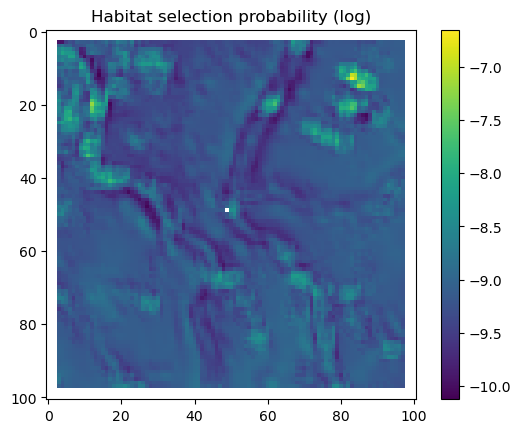

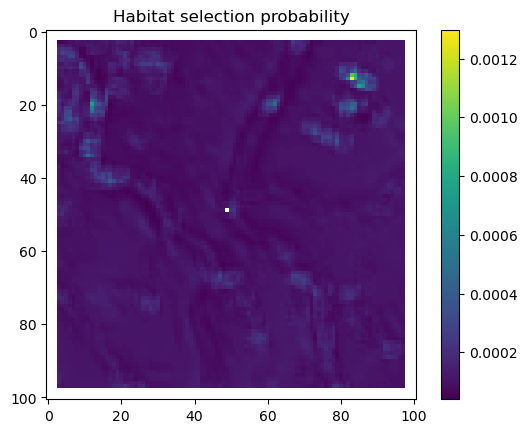

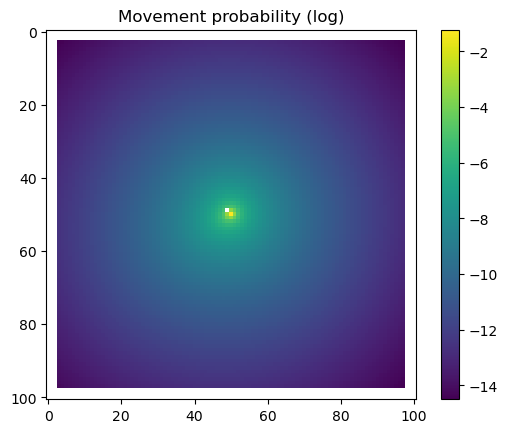

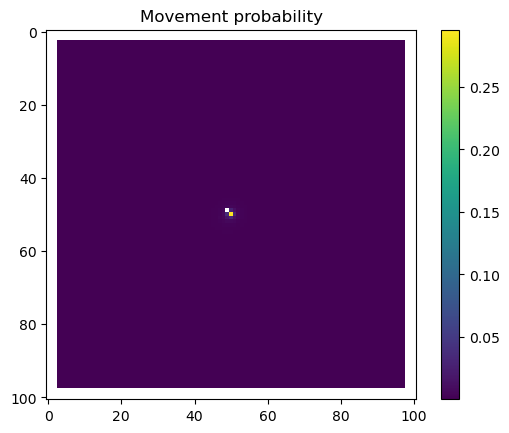

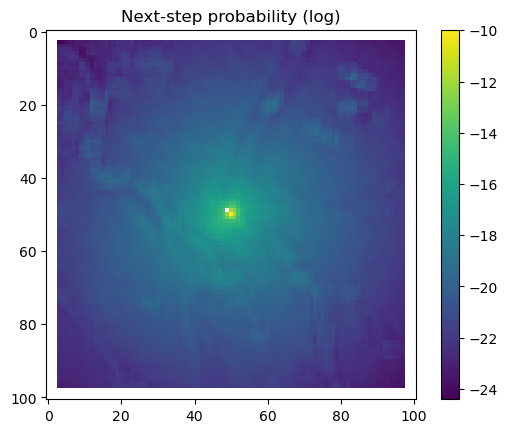

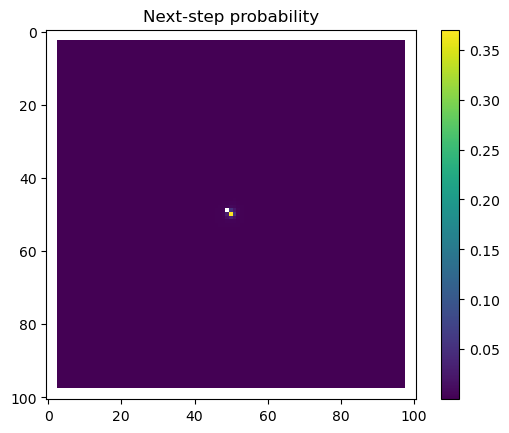

In [ ]:
print(iteration_index)

# -------------------------------------------------------------------------
# Switch the model to evaluation mode (e.g., disables dropout, etc.)
# -------------------------------------------------------------------------
model.eval()

# -------------------------------------------------------------------------
# Pass the inputs through the model; 'test' will have shape [batch, H, W, 2]
# -------------------------------------------------------------------------
test = model((sample_spatial_covs, sample_temporal_covs, sample_prev_bearing))
# test = model((x1, x2, x3))
print(test.shape)

# -------------------------------------------------------------------------
# Extract and exponentiate the habitat density channel
#    (at index 0 in the last dimension)
# -------------------------------------------------------------------------
hab_density = test.detach().cpu().numpy()[0, :, :, 0]
hab_density_exp = np.exp(hab_density)
# print(np.sum(hab_density_exp))  # Debug: check the sum of exponentiated values

# -------------------------------------------------------------------------
# Create masks to remove unwanted edge cells from visualization
#    (setting them to -∞ affects the color scale in plots)
# -------------------------------------------------------------------------
x_mask = np.ones_like(hab_density)
y_mask = np.ones_like(hab_density)

x_mask[:, :3] = -np.inf
x_mask[:, 98:] = -np.inf
y_mask[:3, :] = -np.inf
y_mask[98:, :] = -np.inf

# Create a mask for the next step
sample_target = sample_next_step.squeeze().detach().cpu().numpy()
next_step_mask = np.ones_like(hab_density)
next_step_mask[sample_target==1] = -np.inf

# -------------------------------------------------------------------------
# Apply the masks to the habitat density (log scale) and exponentiated version
# -------------------------------------------------------------------------
hab_density_mask = hab_density * x_mask * y_mask * next_step_mask
hab_density_exp_mask = hab_density_exp * x_mask * y_mask * next_step_mask

# -------------------------------------------------------------------------
# Plot and save the habitat density in log scale
# -------------------------------------------------------------------------
plt.imshow(hab_density_mask)
plt.colorbar()
plt.title('Habitat selection probability (log)')
plt.savefig(f'{output_dir}/hab_{iteration_index}_log_prob.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()

# -------------------------------------------------------------------------
# Plot and save the habitat density in probability (exponentiated) scale
# -------------------------------------------------------------------------
plt.imshow(hab_density_exp_mask)
plt.colorbar()
plt.title('Habitat selection probability')
plt.savefig(f'{output_dir}/hab_{iteration_index}_prob.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()

# -------------------------------------------------------------------------
# Extract and exponentiate the movement density channel
#    (at index 1 in the last dimension)
# -------------------------------------------------------------------------
move_density = test.detach().cpu().numpy()[0, :, :, 1]
move_density_exp = np.exp(move_density)
# print(np.sum(move_density_exp))  # Debug: check the sum of exponentiated values

# -------------------------------------------------------------------------
# Apply the same masking strategy to movement densities
# -------------------------------------------------------------------------
move_density_mask = move_density * x_mask * y_mask * next_step_mask
move_density_exp_mask = move_density_exp * x_mask * y_mask * next_step_mask

# -------------------------------------------------------------------------
# Plot and save the movement density in log scale
# -------------------------------------------------------------------------
plt.imshow(move_density_mask)
plt.colorbar()
plt.title('Movement probability (log)')
plt.savefig(f'{output_dir}/move_{iteration_index}_log_prob.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()

# -------------------------------------------------------------------------
# Plot and save the movement density in probability (exponentiated) scale
# -------------------------------------------------------------------------
plt.imshow(move_density_exp_mask)
plt.colorbar()
plt.title('Movement probability')
plt.savefig(f'{output_dir}/move_{iteration_index}_prob.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()

# -------------------------------------------------------------------------
# Compute the next-step density by adding habitat + movement (log-space)
#     Then exponentiate and normalize
# -------------------------------------------------------------------------
step_density = test[0, :, :, 0] + test[0, :, :, 1]
step_density = step_density.detach().cpu().numpy()
step_density_exp = np.exp(step_density)
# print('Sum of step density exp = ', np.sum(step_density_exp))  # Debug

step_density_exp_norm = step_density_exp / np.sum(step_density_exp)
# print('Sum of step density exp norm = ', np.sum(step_density_exp_norm))  # Debug

# -------------------------------------------------------------------------
# Apply masks to the step densities (log and exponentiated + normalized)
# -------------------------------------------------------------------------
step_density_mask = step_density * x_mask * y_mask * next_step_mask
step_density_exp_norm_mask = step_density_exp_norm * x_mask * y_mask * next_step_mask

# -------------------------------------------------------------------------
# Plot and save the combined next-step probability surface in log scale
# -------------------------------------------------------------------------
plt.imshow(step_density_mask)
plt.colorbar()
plt.title('Next-step probability (log)')
plt.savefig(f'{output_dir}/step_{iteration_index}_log_prob.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()

# -------------------------------------------------------------------------
# Plot and save the combined next-step probability surface in probability scale
# -------------------------------------------------------------------------
plt.imshow(step_density_exp_norm_mask)
plt.colorbar()
plt.title('Next-step probability')
plt.savefig(f'{output_dir}/step_{iteration_index}_prob.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()


# Extracting convolution layer outputs

In the convolutional blocks, each convolutional layer learns a set of **filters** (kernels) that extract different features from the input data. In the habitat selection subnetwork, the convolution filters (and their associated bias parameters - not shown below) are the only parameters that are trained, and it is the filters that transform the set of input covariates into the habitat selection probabilities. They do this by maximising features of the inputs that correlate with observed next-steps.

For each convolutional layer, there are typically a number of filters. For the habitat selection subnetwork, we used 4 filters in the first two layers, and a single filter in the last layer. Each of these filters has a number of **channels** which correspond one-to-one with the input layers. The outputs of the filter channels are then combined to produce a feature map, with a single feature map produced for each filter. In successive layers, the feature maps become the input layers, and the filters operate on these layers. Because there are multiple filters in ech layer, they can 'specialise' in extracting different features from the input layers.

By visualizing and inspecting these filters, and the corresponding feature maps, we can:

- Gain interpretability: Understand what kind of features the network is detecting—e.g., edges, shapes, or textures.
- Debug: Check if the filters have meaningful patterns or if something went wrong (e.g., all zeros or random noise).
- Compare layers: See how early layers often learn low-level patterns while deeper layers learn more abstract features.

We will first set up some activation hooks for storing the feature maps. Activation hooks are placed at certain points within the model's forward pass and store intermediate results. We will also extract the convolution filters (which are weights of the model and as such don't require hooks - we can access them directly).

We will then run the sample covariates through the model and extract the feature maps from the habitat selection convolutional block, and plot them along with the covariates and convolution filters.

Note that there are also ReLU activation functions in the convolutional blocks, which are not shown below. These are applied to the feature maps, and set all negative values to zero. They are not learned parameters, but are part of the forward pass of the model.


## Convolutional layer 1

### Activation hook

In [ ]:
# -----------------------------------------------------------
# Create a dictionary to store activation outputs
# -----------------------------------------------------------
activation = {}

def get_activation(name):
    """
    Returns a hook function that can be registered on a layer
    to capture its output (i.e., feature maps) after the forward pass.

    Args:
        name (str): The key under which the activation is stored in the 'activation' dict.
    """
    def hook(model, input, output):
        # Detach and save the layer's output in the dictionary
        activation[name] = output.detach()
    return hook

# -----------------------------------------------------------
# Register a forward hook on the first convolution layer
#    in the model's 'conv_habitat' block
# -----------------------------------------------------------
model.conv_habitat.conv2d[0].register_forward_hook(get_activation("hab_conv1"))

# -----------------------------------------------------------
# Perform a forward pass through the model with the desired input
#    The feature maps from the hooked layer will be stored in 'activation'
# -----------------------------------------------------------
# out = model((x1, x2, x3))  # e.g., model((spatial_data_x, scalars_to_grid, bearing_x))
test = model((sample_spatial_covs, sample_temporal_covs, sample_prev_bearing))

# -----------------------------------------------------------
# Retrieve the captured feature maps from the dictionary
#    and move them to the CPU for inspection
# -----------------------------------------------------------
feat_maps1 = activation["hab_conv1"].cpu()
print("Feature map shape:", feat_maps1.shape)
# Typically shape: (batch_size, out_channels, height, width)

# -----------------------------------------------------------
# Visualize the feature maps for the first sample in the batch
# -----------------------------------------------------------
feat_maps1_sample = feat_maps1[0]  # Shape: (out_channels, H, W)
num_maps1 = feat_maps1_sample.shape[0]
print("Number of feature maps:", num_maps1)



Feature map shape: torch.Size([1, 4, 101, 101])
Number of feature maps: 4


### Stack spatial and scalar (as grid) covariates

For plotting. Also create a vector of names to index over.

torch.Size([1, 4, 101, 101])


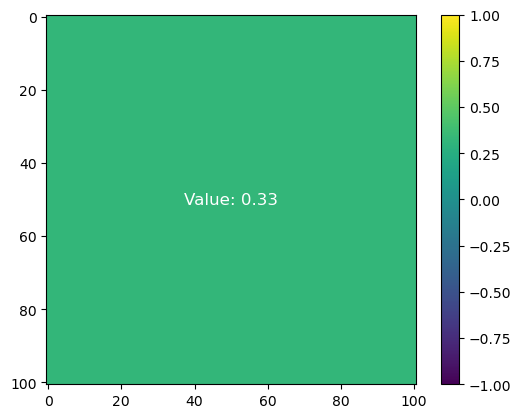

torch.Size([1, 8, 101, 101])


In [ ]:
# Create an instance of the scalar-to-grid block using model parameters
test_block = deepSSF_model.Scalar_to_Grid_Block(params)

# Convert scalars into spatial grid representation
scalar_maps = test_block(sample_temporal_covs).detach().cpu()
# print(scalar_maps)  # Optionally, to inspect raw output
print(scalar_maps.shape)  # Check the shape of the generated spatial maps

# Visualize one channel of the first example's scalar map
# (Values are should be repeated across the grid for each scalar)
scalar_index = 2  # Change this index to visualize other scalar maps
plt.imshow(scalar_maps[0, scalar_index]) # change the second index to see the other scalar maps
plt.colorbar()
plt.clim(-1, 1) # Set the color limits to match the range of the scalar values (sine and cosine of temporal parameters)
plt.text(scalar_maps.shape[2] // 2, scalar_maps.shape[3] // 2,
         f'Value: {round(sample_temporal_covs[0, scalar_index].item(), 2)}',
         ha='center', va='center', color='white', fontsize=12)
plt.show()

covariate_stack = torch.cat([sample_spatial_covs.detach().cpu(), scalar_maps], dim=1)
print(covariate_stack.shape)

# covariate_names = ['NDVI', 'Canopy cover', 'Herbaceous vegetation', 'Slope',
#                    'Hour sin1', 'Hour cos1', 'Hour sin2', 'Hour cos2',
#                    'yday sin1', 'yday cos1', 'yday sin2', 'yday cos2']

covariate_names = ['NDVI', 'Canopy cover', 'Herbaceous vegetation', 'Slope',
                   'Hour sin1', 'Hour cos1', 'yday sin1', 'yday cos1']

### Extract filters and plot

Sequential(
  (0): Conv2d(8, 4, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): ReLU()
  (2): Conv2d(4, 4, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (3): ReLU()
  (4): Conv2d(4, 1, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
)
Filters shape: torch.Size([4, 8, 3, 3])
8


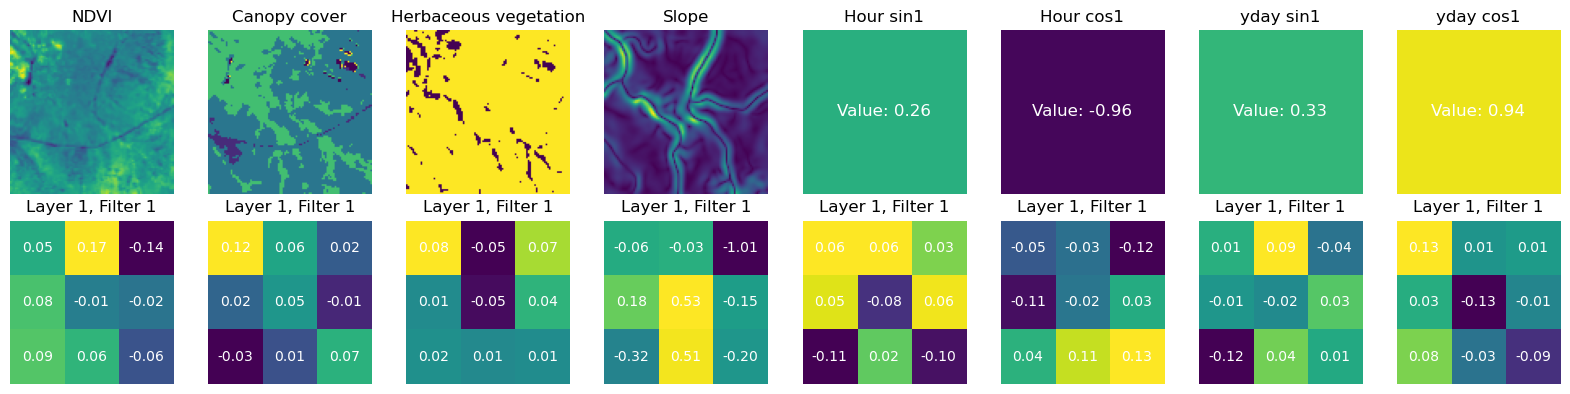

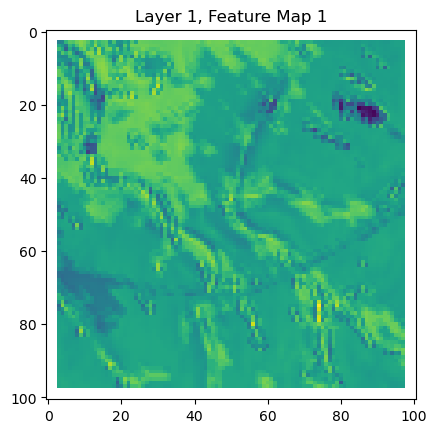

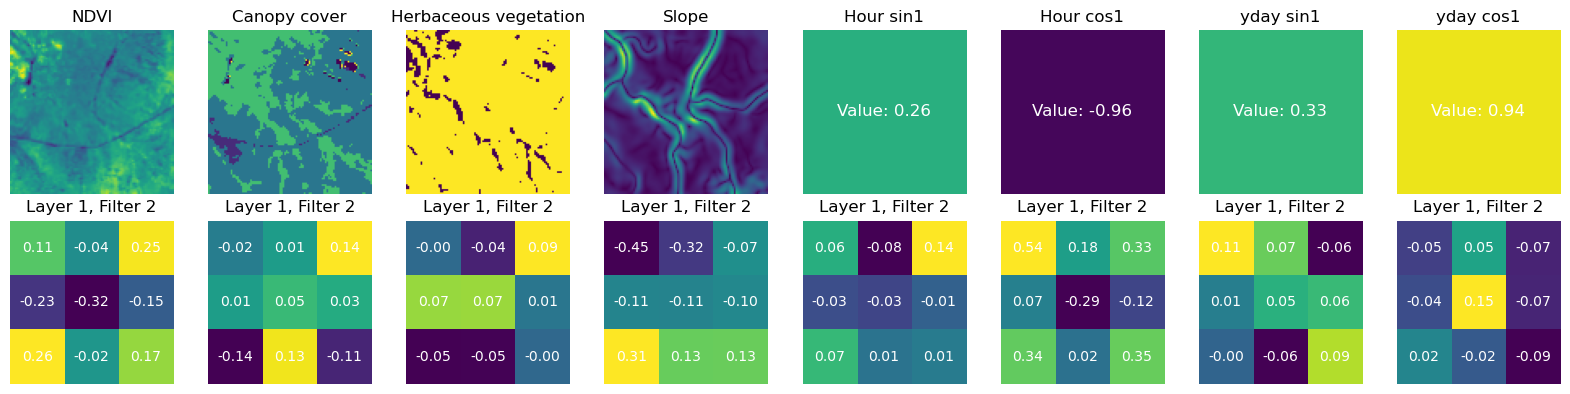

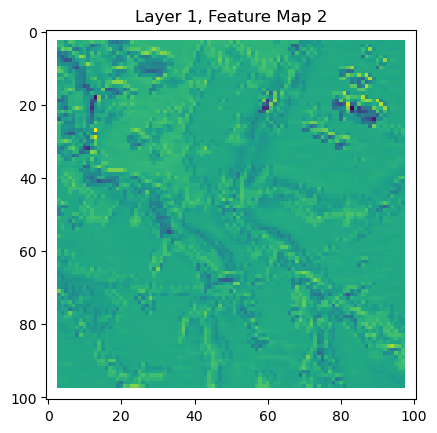

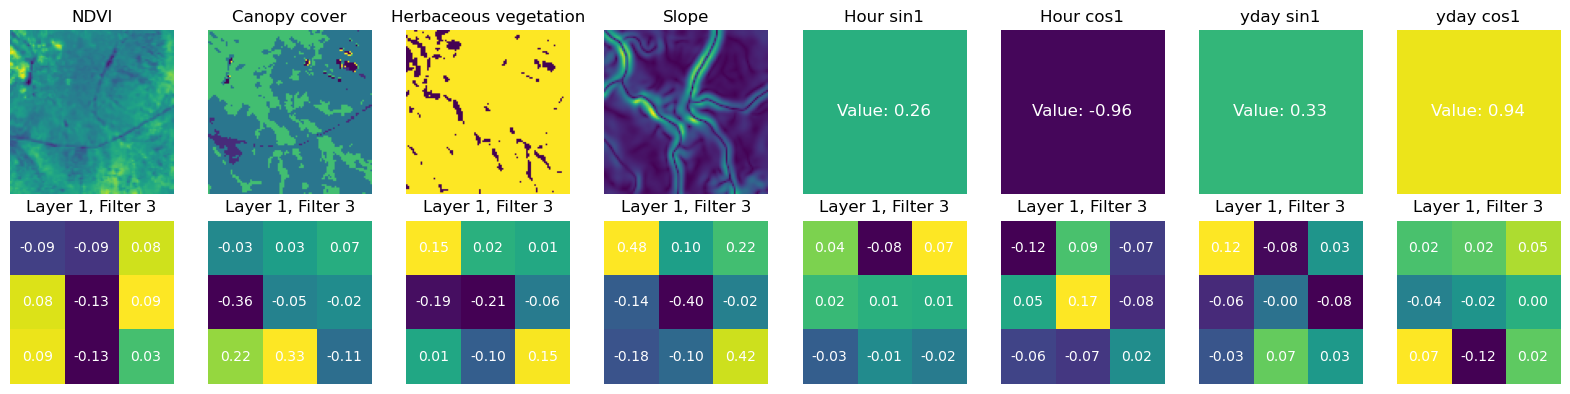

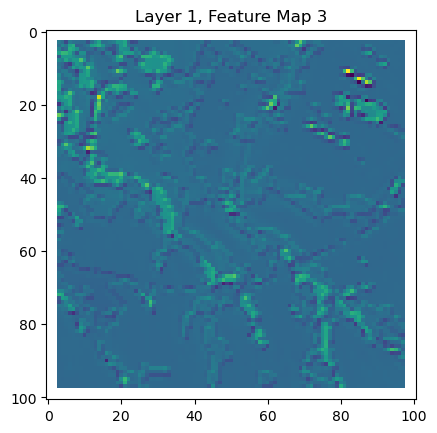

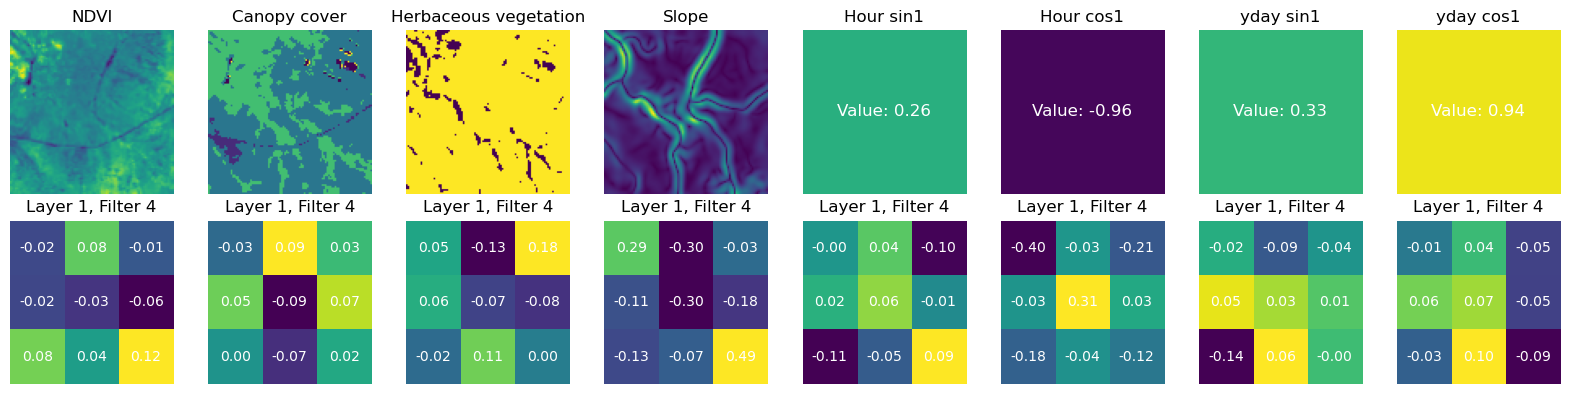

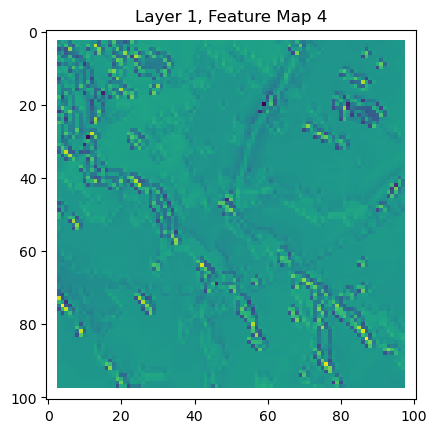

In [ ]:
# -------------------------------------------------------------------------
# Check or print the convolution layer in conv_habitat (for debugging)
# -------------------------------------------------------------------------
print(model.conv_habitat.conv2d)

# -------------------------------------------------------------------------
# Set the model to evaluation mode (disables dropout, etc.)
# -------------------------------------------------------------------------
model.eval()

# -------------------------------------------------------------------------
# Extract the weights (filters) from the first convolution layer in conv_habitat
# -------------------------------------------------------------------------
filters_c1 = model.conv_habitat.conv2d[0].weight.data.clone().cpu()
print("Filters shape:", filters_c1.shape)
# Typically (out_channels, in_channels, kernel_height, kernel_width)

# -------------------------------------------------------------------------
# Visualize each filter’s first channel in a grid of subplots
# -------------------------------------------------------------------------
num_filters_c1 = filters_c1.shape[1]
print(num_filters_c1)

for z in range(num_maps1):

    fig, axes = plt.subplots(2, num_filters_c1, figsize=(2*num_filters_c1, 4))
    for i in range(num_filters_c1):

        # Add the covariates as the first row of subplots
        axes[0,i].imshow(covariate_stack[0, i].detach().cpu().numpy(), cmap='viridis')
        axes[0,i].axis('off')
        axes[0,i].set_title(f'{covariate_names[i]}')
        if i > 3:
            im1 = axes[0,i].imshow(covariate_stack[0, i].detach().cpu().numpy(), cmap='viridis')
            im1.set_clim(-1, 1)
            axes[0,i].text(scalar_maps.shape[2] // 2, scalar_maps.shape[3] // 2,
                f'Value: {round(sample_temporal_covs[0, i-4].item(), 2)}',
                ha='center', va='center', color='white', fontsize=12)

        kernel = filters_c1[z, i, :, :]  # Show the first input channel
        im = axes[1,i].imshow(kernel, cmap='viridis')
        axes[1,i].axis('off')
        axes[1,i].set_title(f'Layer 1, Filter {z+1}')
        # Annotate each cell with the numeric value
        for (j, k), val in np.ndenumerate(kernel):
            axes[1,i].text(k, j, f'{val:.2f}', ha='center', va='center', color='white')

    plt.tight_layout()
    plt.savefig(f'{output_dir}/conv_layer1_filters{z}.png', dpi=300, bbox_inches='tight')
    plt.show()


    # -----------------------------------------------------------
    # Loop over each feature map channel and save them as images.
    #    Multiply by x_mask * y_mask if you need to mask out edges.
    # -----------------------------------------------------------

    plt.figure()
    plt.imshow(feat_maps1_sample[z].numpy() * x_mask * y_mask, cmap='viridis')
    plt.title(f"Layer 1, Feature Map {z+1}")
    # Hide axis if you prefer: plt.axis('off')
    plt.savefig(f'{output_dir}/conv_layer1_feature_map{z}.png', dpi=300, bbox_inches='tight')
    plt.show()



## Convolutional layer 2

### Activation hook

In [ ]:
# -----------------------------------------------------------
# Register a forward hook on the second convolution layer
#    in the model's 'conv_habitat' block
# -----------------------------------------------------------
model.conv_habitat.conv2d[2].register_forward_hook(get_activation("hab_conv2"))

# -----------------------------------------------------------
# Perform a forward pass through the model with the desired input
#    The feature maps from the hooked layer will be stored in 'activation'
# -----------------------------------------------------------
# out = model((x1, x2, x3))  # e.g., model((spatial_data_x, scalars_to_grid, bearing_x))
test = model((sample_spatial_covs, sample_temporal_covs, sample_prev_bearing))

# -----------------------------------------------------------
# Retrieve the captured feature maps from the dictionary
#    and move them to the CPU for inspection
# -----------------------------------------------------------
feat_maps2 = activation["hab_conv2"].cpu()
print("Feature map shape:", feat_maps2.shape)
# Typically shape: (batch_size, out_channels, height, width)

# -----------------------------------------------------------
# Visualize the feature maps for the first sample in the batch
# -----------------------------------------------------------
feat_maps2_sample = feat_maps2[0]  # Shape: (out_channels, H, W)
num_maps2 = feat_maps2_sample.shape[0]
print("Number of feature maps:", num_maps2)



Feature map shape: torch.Size([1, 4, 101, 101])
Number of feature maps: 4


### Extract filters and plot

Filters shape: torch.Size([4, 4, 3, 3])
4


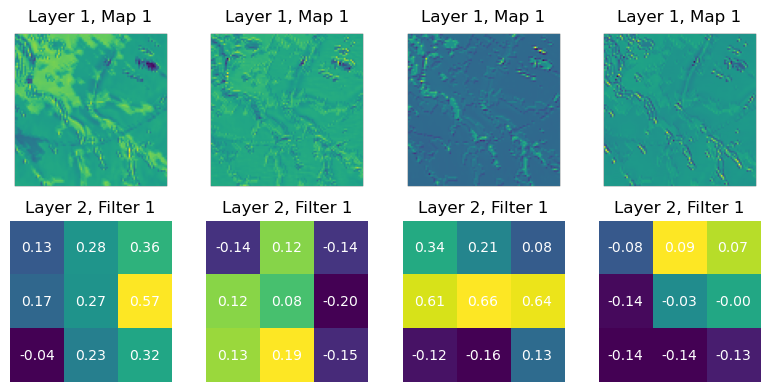

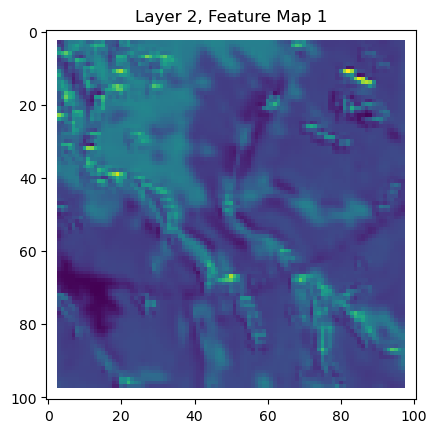

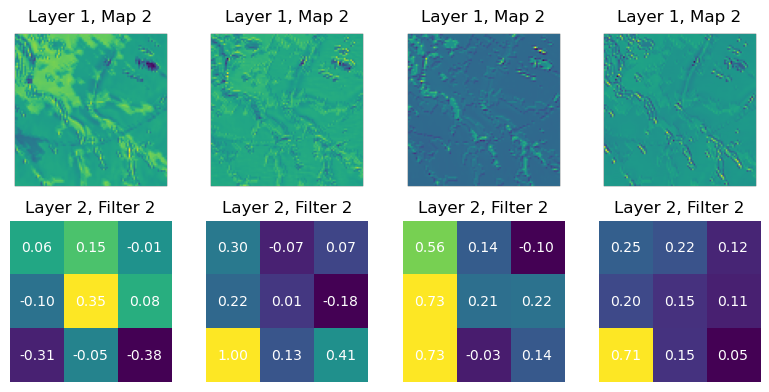

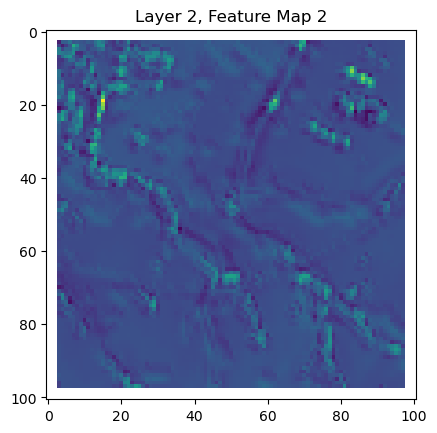

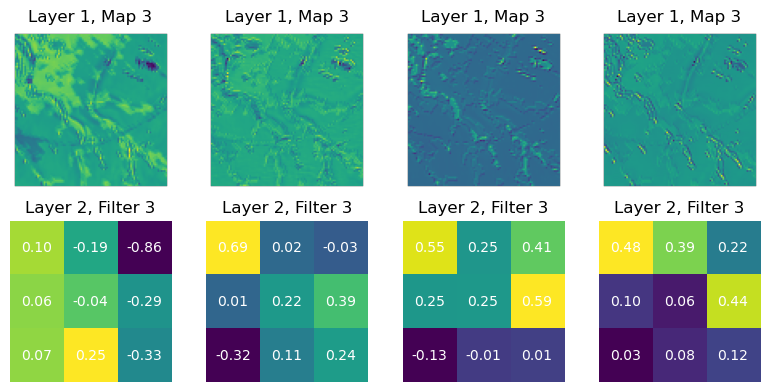

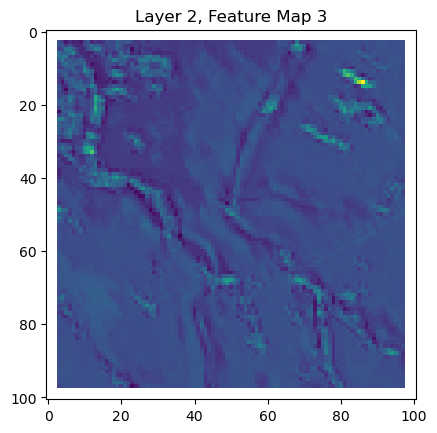

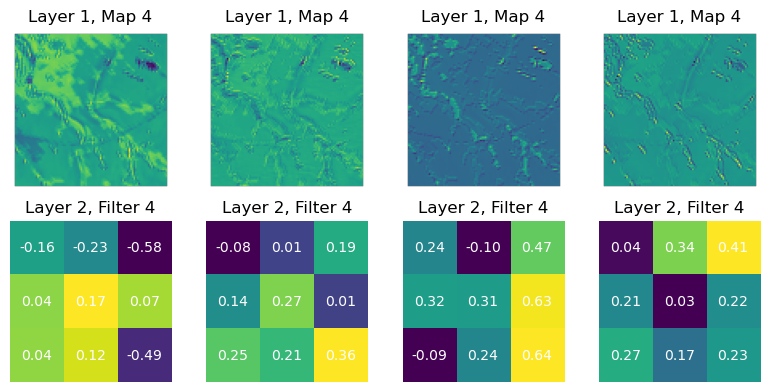

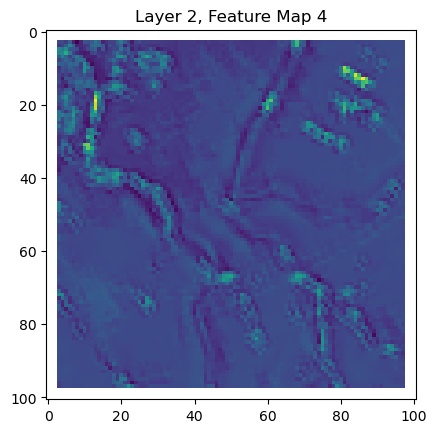

In [ ]:
# -------------------------------------------------------------------------
# Extract the weights (filters) from the second convolution layer in conv_habitat
# -------------------------------------------------------------------------
filters_c2 = model.conv_habitat.conv2d[2].weight.data.clone().cpu()
print("Filters shape:", filters_c2.shape)
# Typically (out_channels, in_channels, kernel_height, kernel_width)

# -------------------------------------------------------------------------
# Visualize each filter’s first channel in a grid of subplots
# -------------------------------------------------------------------------
num_filters_c2 = filters_c2.shape[1]
print(num_filters_c2)

for z in range(num_maps2):

    fig, axes = plt.subplots(2, num_filters_c2, figsize=(2*num_filters_c2, 4))
    for i in range(num_filters_c2):

        # Add the covariates as the first row of subplots
        axes[0,i].imshow(feat_maps1_sample[i].numpy() * x_mask * y_mask, cmap='viridis')
        axes[0,i].axis('off')
        axes[0,i].set_title(f"Layer 1, Map {z+1}")

        # if i > 3:
        #     im1 = axes[0,i].imshow(covariate_stack[0, i].detach().cpu().numpy(), cmap='viridis')
        #     im1.set_clim(-1, 1)
        #     axes[0,i].text(scalar_maps.shape[2] // 2, scalar_maps.shape[3] // 2,
        #         f'Value: {round(x2[0, i-4].item(), 2)}',
        #         ha='center', va='center', color='white', fontsize=12)

        kernel = filters_c2[z, i, :, :]  # Show the first input channel
        im = axes[1,i].imshow(kernel, cmap='viridis')
        axes[1,i].axis('off')
        axes[1,i].set_title(f'Layer 2, Filter {z+1}')
        # Annotate each cell with the numeric value
        for (j, k), val in np.ndenumerate(kernel):
            axes[1,i].text(k, j, f'{val:.2f}', ha='center', va='center', color='white')

    plt.tight_layout()
    plt.savefig(f'{output_dir}/conv_layer2_filters{z}.png', dpi=300, bbox_inches='tight')
    plt.show()


    # -----------------------------------------------------------
    # 6. Loop over each feature map channel and save them as images.
    #    Multiply by x_mask * y_mask if you need to mask out edges.
    # -----------------------------------------------------------

    plt.figure()
    plt.imshow(feat_maps2_sample[z].numpy() * x_mask * y_mask, cmap='viridis')
    plt.title(f"Layer 2, Feature Map {z+1}")
    # Hide axis if you prefer: plt.axis('off')
    plt.savefig(f'{output_dir}/conv_layer2_feature_map{z}.png', dpi=300, bbox_inches='tight')
    plt.show()



## Convolutional layer 3

### Activation hook

In [ ]:
# -----------------------------------------------------------
# Register a forward hook on the third convolution layer
#    in the model's 'conv_habitat' block
# -----------------------------------------------------------
model.conv_habitat.conv2d[4].register_forward_hook(get_activation("hab_conv3"))

# -----------------------------------------------------------
# Perform a forward pass through the model with the desired input
#    The feature maps from the hooked layer will be stored in 'activation'
# -----------------------------------------------------------
# out = model((x1, x2, x3))  # e.g., model((spatial_data_x, scalars_to_grid, bearing_x))
test = model((sample_spatial_covs, sample_temporal_covs, sample_prev_bearing))

# -----------------------------------------------------------
# Retrieve the captured feature maps from the dictionary
#    and move them to the CPU for inspection
# -----------------------------------------------------------
feat_maps3 = activation["hab_conv3"].cpu()
print("Feature map shape:", feat_maps3.shape)
# Typically shape: (batch_size, out_channels, height, width)

# -----------------------------------------------------------
# Visualize the feature maps for the first sample in the batch
# -----------------------------------------------------------
feat_maps3_sample = feat_maps3[0]  # Shape: (out_channels, H, W)
num_maps3 = feat_maps3_sample.shape[0]
print("Number of feature maps:", num_maps3)



Feature map shape: torch.Size([1, 1, 101, 101])
Number of feature maps: 1


### Extract filters and plot

Filters shape: torch.Size([1, 4, 3, 3])
4


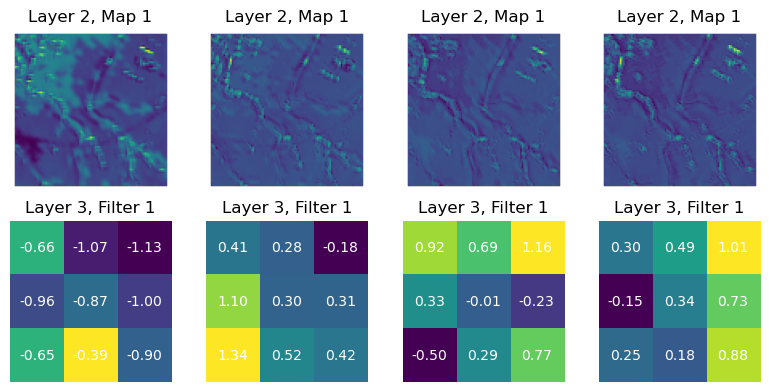

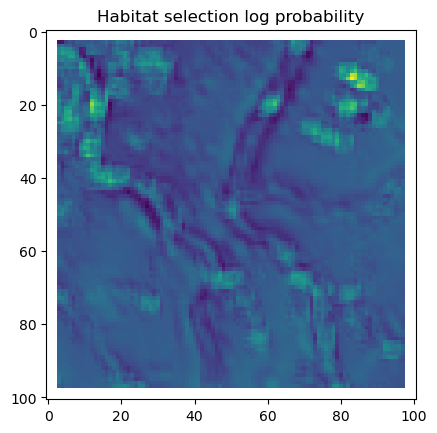

In [ ]:
# -------------------------------------------------------------------------
# Extract the weights (filters) from the second convolution layer in conv_habitat
# -------------------------------------------------------------------------
filters_c3 = model.conv_habitat.conv2d[4].weight.data.clone().cpu()
print("Filters shape:", filters_c3.shape)
# Typically (out_channels, in_channels, kernel_height, kernel_width)

# -------------------------------------------------------------------------
# Visualize each filter’s first channel in a grid of subplots
# -------------------------------------------------------------------------
num_filters_c3 = filters_c3.shape[1]
print(num_filters_c3)

for z in range(num_maps3):

    fig, axes = plt.subplots(2, num_filters_c3, figsize=(2*num_filters_c3, 4))
    for i in range(num_filters_c3):

        # Add the covariates as the first row of subplots
        axes[0,i].imshow(feat_maps2_sample[i].numpy() * x_mask * y_mask, cmap='viridis')
        axes[0,i].axis('off')
        axes[0,i].set_title(f"Layer 2, Map {z+1}")


        kernel = filters_c3[z, i, :, :]  # Show the first input channel
        im = axes[1,i].imshow(kernel, cmap='viridis')
        axes[1,i].axis('off')
        axes[1,i].set_title(f'Layer 3, Filter {z+1}')
        # Annotate each cell with the numeric value
        for (j, k), val in np.ndenumerate(kernel):
            axes[1,i].text(k, j, f'{val:.2f}', ha='center', va='center', color='white')

    plt.tight_layout()
    plt.savefig(f'{output_dir}/conv_layer3_filters{z}.png', dpi=300, bbox_inches='tight')
    plt.show()


    # -----------------------------------------------------------
    # 6. Loop over each feature map channel and save them as images.
    #    Multiply by x_mask * y_mask if you need to mask out edges.
    # -----------------------------------------------------------

    plt.figure()
    plt.imshow(feat_maps3_sample[z].numpy() * x_mask * y_mask, cmap='viridis')
    plt.title(f"Habitat selection log probability")
    # Hide axis if you prefer: plt.axis('off')
    plt.savefig(f'{output_dir}/conv_layer3_feature_map{z}.png', dpi=300, bbox_inches='tight')
    plt.show()



# Checking estimated movement parameters

Similarly to the convolutional layers, we can set hooks to extract the predicted movement parameters from the model, and assess how variable that is across samples.

In [ ]:
torch.cuda.empty_cache()

# -------------------------------------------------------------------------
# Create a list to store the intermediate output from the fully connected
#    movement sub-network (fcn_movement_all)
# -------------------------------------------------------------------------
intermediate_output = []

def hook(module, input, output):
    """
    Hook function that captures the output of the specified layer
    (fcn_movement_all) during the forward pass.
    """
    intermediate_output.append(output)

# -------------------------------------------------------------------------
# Register the forward hook on 'fcn_movement_all', so its outputs
#    are recorded every time the model does a forward pass.
# -------------------------------------------------------------------------
hook_handle = model.fcn_movement_all.register_forward_hook(hook)

# -------------------------------------------------------------------------
# Perform a forward pass with the model in evaluation mode,
#    disabling gradient computation.
# -------------------------------------------------------------------------
model.eval()
with torch.no_grad():
    final_output = model((sample_spatial_covs, sample_temporal_covs, sample_prev_bearing))

# -------------------------------------------------------------------------
# Inspect the captured intermediate output
#    'intermediate_output[0]' corresponds to the first (and only) forward pass.
# -------------------------------------------------------------------------
print("Intermediate output shape:", intermediate_output[0].shape)
print("Intermediate output values:", intermediate_output[0][0])

# -------------------------------------------------------------------------
# Remove the hook to avoid repeated capturing in subsequent passes
# -------------------------------------------------------------------------
hook_handle.remove()

# -------------------------------------------------------------------------
# Unpack the parameters from the FCN output (assumes a specific ordering)
# -------------------------------------------------------------------------
gamma_shape1, gamma_scale1, gamma_weight1, \
gamma_shape2, gamma_scale2, gamma_weight2, \
vonmises_mu1, vonmises_kappa1, vonmises_weight1, \
vonmises_mu2, vonmises_kappa2, vonmises_weight2 = intermediate_output[0][0]

# -------------------------------------------------------------------------
# Convert parameters from log-space (if applicable) and print them
#    Gamma and von Mises parameters
# -------------------------------------------------------------------------
# --- Gamma #1 ---
print("Gamma shape 1:", torch.exp(gamma_shape1))
print("Gamma scale 1:", torch.exp(gamma_scale1))
print("Gamma weight 1:",
      torch.exp(gamma_weight1) / (torch.exp(gamma_weight1) + torch.exp(gamma_weight2)))

# --- Gamma #2 ---
print("Gamma shape 2:", torch.exp(gamma_shape2))
print("Gamma scale 2:", torch.exp(gamma_scale2) * 500)  # scale factor 500
print("Gamma weight 2:",
      torch.exp(gamma_weight2) / (torch.exp(gamma_weight1) + torch.exp(gamma_weight2)))

# --- von Mises #1 ---
# % (2*np.pi) ensures the mu (angle) is wrapped within [0, 2π)
print("Von Mises mu 1:", vonmises_mu1 % (2*np.pi))
print("Von Mises kappa 1:", torch.exp(vonmises_kappa1))
print("Von Mises weight 1:",
      torch.exp(vonmises_weight1) / (torch.exp(vonmises_weight1) + torch.exp(vonmises_weight2)))

# --- von Mises #2 ---
print("Von Mises mu 2:", vonmises_mu2 % (2*np.pi))
print("Von Mises kappa 2:", torch.exp(vonmises_kappa2))
print("Von Mises weight 2:",
      torch.exp(vonmises_weight2) / (torch.exp(vonmises_weight1) + torch.exp(vonmises_weight2)))


Intermediate output shape: torch.Size([1, 12])
Intermediate output values: tensor([-0.6870,  2.3772,  0.4208, -0.7495, -0.1895,  0.2825,  0.2370, -3.4588,
         1.2351, -0.0132,  1.4680, -0.1185], device='mps:0')
Gamma shape 1: tensor(0.5031, device='mps:0')
Gamma scale 1: tensor(10.7742, device='mps:0')
Gamma weight 1: tensor(0.5345, device='mps:0')
Gamma shape 2: tensor(0.4726, device='mps:0')
Gamma scale 2: tensor(413.6990, device='mps:0')
Gamma weight 2: tensor(0.4655, device='mps:0')
Von Mises mu 1: tensor(0.2370, device='mps:0')
Von Mises kappa 1: tensor(0.0315, device='mps:0')
Von Mises weight 1: tensor(0.7947, device='mps:0')
Von Mises mu 2: tensor(6.2700, device='mps:0')
Von Mises kappa 2: tensor(4.3406, device='mps:0')
Von Mises weight 2: tensor(0.2053, device='mps:0')


## Plot the movement distributions

We can use the movement parameters to plot the step length and turning angle distributions for the sample covariates.

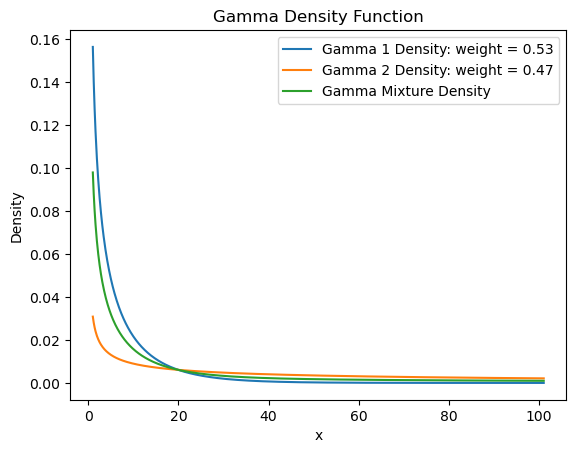

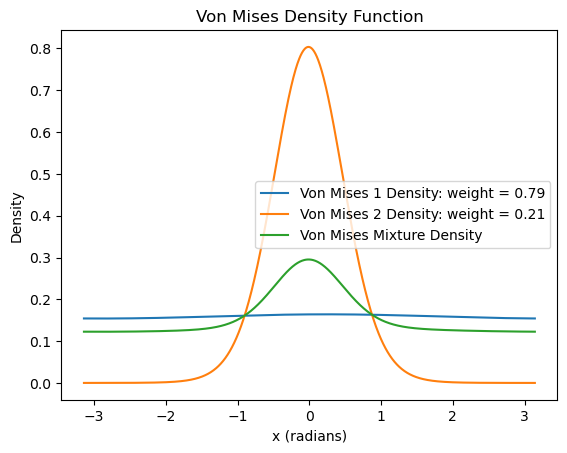

In [ ]:
# -------------------------------------------------------------------------
# Define helper functions for calculating Gamma and von Mises log-densities
# -------------------------------------------------------------------------
def gamma_density(x, shape, scale):
    """
    Computes the log of the Gamma density for each value in x.

    Args:
      x (Tensor): Input values for which to compute the density.
      shape (float): Gamma shape parameter
      scale (float): Gamma scale parameter

    Returns:
      Tensor: The log of the Gamma probability density at each x.
    """
    return -1*torch.lgamma(shape) - shape*torch.log(scale) \
           + (shape - 1)*torch.log(x) - x/scale

def vonmises_density(x, kappa, vm_mu):
    """
    Computes the log of the von Mises density for each value in x.

    Args:
      x (Tensor): Input angles in radians.
      kappa (float): Concentration parameter (kappa)
      vm_mu (float): Mean direction parameter (mu)

    Returns:
      Tensor: The log of the von Mises probability density at each x.
    """
    return kappa*torch.cos(x - vm_mu) - 1*(np.log(2*torch.pi) + torch.log(torch.special.i0(kappa)))


# -------------------------------------------------------------------------
# Round and display the mixture weights for the Gamma distributions
# -------------------------------------------------------------------------
gamma_weight1_recovered = torch.exp(gamma_weight1)/(torch.exp(gamma_weight1) + torch.exp(gamma_weight2))
rounded_gamma_weight1 = round(gamma_weight1_recovered.item(), 2)

gamma_weight2_recovered = torch.exp(gamma_weight2)/(torch.exp(gamma_weight1) + torch.exp(gamma_weight2))
rounded_gamma_weight2 = round(gamma_weight2_recovered.item(), 2)

# -------------------------------------------------------------------------
# Round and display the mixture weights for the von Mises distributions
# -------------------------------------------------------------------------
vonmises_weight1_recovered = torch.exp(vonmises_weight1)/(torch.exp(vonmises_weight1) + torch.exp(vonmises_weight2))
rounded_vm_weight1 = round(vonmises_weight1_recovered.item(), 2)

vonmises_weight2_recovered = torch.exp(vonmises_weight2)/(torch.exp(vonmises_weight1) + torch.exp(vonmises_weight2))
rounded_vm_weight2 = round(vonmises_weight2_recovered.item(), 2)


# -------------------------------------------------------------------------
# 1. Plotting the Gamma mixture distribution
#    a) Generate x values
#    b) Compute individual Gamma log densities
#    c) Exponentiate and combine using recovered weights
# -------------------------------------------------------------------------
x_values = torch.linspace(1, 101, 1000).to(device)
gamma1_density = gamma_density(x_values, torch.exp(gamma_shape1), torch.exp(gamma_scale1))
gamma2_density = gamma_density(x_values, torch.exp(gamma_shape2), torch.exp(gamma_scale2)*500)
gamma_mixture_density = gamma_weight1_recovered*torch.exp(gamma1_density) \
                        + gamma_weight2_recovered*torch.exp(gamma2_density)

# Move results to CPU and convert to NumPy for plotting
x_values_np = x_values.cpu().numpy()
gamma1_density_np = np.exp(gamma1_density.cpu().numpy())
gamma2_density_np = np.exp(gamma2_density.cpu().numpy())
gamma_mixture_density_np = gamma_mixture_density.cpu().numpy()

# -------------------------------------------------------------------------
# 2. Plot the Gamma distributions and their mixture
# -------------------------------------------------------------------------
filename_gamma_distributions = f'{output_dir}/gamma_distributions.png'

plt.plot(x_values_np, gamma1_density_np, label=f'Gamma 1 Density: weight = {rounded_gamma_weight1}')
plt.plot(x_values_np, gamma2_density_np, label=f'Gamma 2 Density: weight = {rounded_gamma_weight2}')
plt.plot(x_values_np, gamma_mixture_density_np, label='Gamma Mixture Density')
plt.xlabel('x')
plt.ylabel('Density')
plt.title('Gamma Density Function')
plt.legend()
plt.savefig(filename_gamma_distributions, dpi=300, bbox_inches='tight')
plt.show()


# -------------------------------------------------------------------------
# 3. Plotting the von Mises mixture distribution
#    a) Generate x values from -π to π
#    b) Compute individual von Mises log densities
#    c) Exponentiate and combine using recovered weights
# -------------------------------------------------------------------------
x_values = torch.linspace(-np.pi, np.pi, 1000).to(device)
vonmises1_density = vonmises_density(x_values, torch.exp(vonmises_kappa1), vonmises_mu1)
vonmises2_density = vonmises_density(x_values, torch.exp(vonmises_kappa2), vonmises_mu2)
vonmises_mixture_density = vonmises_weight1_recovered*torch.exp(vonmises1_density) \
                           + vonmises_weight2_recovered*torch.exp(vonmises2_density)

# Move results to CPU and convert to NumPy for plotting
x_values_np = x_values.cpu().numpy()
vonmises1_density_np = np.exp(vonmises1_density.cpu().numpy())
vonmises2_density_np = np.exp(vonmises2_density.cpu().numpy())
vonmises_mixture_density_np = vonmises_mixture_density.cpu().numpy()

# -------------------------------------------------------------------------
# 4. Plot the von Mises distributions and their mixture
# -------------------------------------------------------------------------
filename_vonmises_distributions = f'{output_dir}/vonmises_distributions.png'

plt.plot(x_values_np, vonmises1_density_np, label=f'Von Mises 1 Density: weight = {rounded_vm_weight1}')
plt.plot(x_values_np, vonmises2_density_np, label=f'Von Mises 2 Density: weight = {rounded_vm_weight2}')
plt.plot(x_values_np, vonmises_mixture_density_np, label='Von Mises Mixture Density')
plt.xlabel('x (radians)')
plt.ylabel('Density')
plt.title('Von Mises Density Function')
# plt.ylim(0, 0.5)  # Set a limit for the y-axis
plt.legend()
plt.savefig(filename_vonmises_distributions, dpi=300, bbox_inches='tight')
plt.show()


## Generate a distribution of movement parameters

To see how variable the movement parameters are across samples, we can generate a distribution of movement parameters from a batch of samples.

We take the code from above that we used to create the DataLoader for the test data and increase the batch size (to get more samples to create the distribution from).

As we're not using the test dataset any more, we'll just put all of the samples in the same batch, and generate movement parameters for all of them.

In [ ]:
# To use all of the test samples
print(f'There are {len(dataset_test)} samples in the test dataset')

# batch_size_test = len(dataset_test) # batch size
batch_size_test = 1000 # batch size

dataloader_test = DataLoader(dataset=dataset_test, batch_size=batch_size_test, shuffle=True)

torch.cuda.empty_cache()

There are 10355 samples in the test dataset


Take all of the samples from the test dataset and put them in a single batch.

In [ ]:
# -----------------------------------------------------------
# Fetch a batch of data from the training dataloader
# -----------------------------------------------------------
x1_batch, x2_batch, x3_batch, labels = next(iter(dataloader_test))

# Move the input batches to the same device as the model
x1_batch = x1_batch.to(device)
x2_batch = x2_batch.to(device)
x3_batch = x3_batch.to(device)

# -----------------------------------------------------------
# Register a forward hook to capture the outputs
#    from 'fcn_movement_all' during the forward pass
# -----------------------------------------------------------
hook_handle = model.fcn_movement_all.register_forward_hook(hook)

# -----------------------------------------------------------
# Perform a forward pass in evaluation mode to generate
#    and capture the sub-network's outputs in 'intermediate_output'
# -----------------------------------------------------------
model.eval()  # Disables certain layers like dropout

# Pass the batch through the model
final_output = model((x1_batch, x2_batch, x3_batch))

# -----------------------------------------------------------
# Prepare lists to store the distribution parameters
#    for each sample in the batch
# -----------------------------------------------------------
gamma_shape1_list = []
gamma_scale1_list = []
gamma_weight1_list = []
gamma_shape2_list = []
gamma_scale2_list = []
gamma_weight2_list = []
vonmises_mu1_list = []
vonmises_kappa1_list = []
vonmises_weight1_list = []
vonmises_mu2_list = []
vonmises_kappa2_list = []
vonmises_weight2_list = []

# -----------------------------------------------------------
# Extract parameters from 'intermediate_output'
#    for every sample in the batch
# -----------------------------------------------------------
for batch_output in intermediate_output:
    # Each 'batch_output' corresponds to one forward pass;
    # it might contain multiple samples if the batch size > 1
    for sample_output in batch_output:
        # Unpack the 12 parameters of the Gamma and von Mises mixtures
        gamma_shape1, gamma_scale1, gamma_weight1, \
        gamma_shape2, gamma_scale2, gamma_weight2, \
        vonmises_mu1, vonmises_kappa1, vonmises_weight1, \
        vonmises_mu2, vonmises_kappa2, vonmises_weight2 = sample_output

        # Convert log-space parameters to real space, then store
        gamma_shape1_list.append(torch.exp(gamma_shape1).item())
        gamma_scale1_list.append(torch.exp(gamma_scale1).item())
        gamma_weight1_list.append(
            (torch.exp(gamma_weight1)/(torch.exp(gamma_weight1) + torch.exp(gamma_weight2))).item()
        )
        gamma_shape2_list.append(torch.exp(gamma_shape2).item())
        gamma_scale2_list.append((torch.exp(gamma_scale2)*500).item())  # scale factor 500
        gamma_weight2_list.append(
            (torch.exp(gamma_weight2)/(torch.exp(gamma_weight1) + torch.exp(gamma_weight2))).item()
        )
        vonmises_mu1_list.append((vonmises_mu1 % (2*np.pi)).item())
        vonmises_kappa1_list.append(torch.exp(vonmises_kappa1).item())
        vonmises_weight1_list.append(
            (torch.exp(vonmises_weight1)/(torch.exp(vonmises_weight1) + torch.exp(vonmises_weight2))).item()
        )
        vonmises_mu2_list.append((vonmises_mu2 % (2*np.pi)).item())
        vonmises_kappa2_list.append(torch.exp(vonmises_kappa2).item())
        vonmises_weight2_list.append(
            (torch.exp(vonmises_weight2)/(torch.exp(vonmises_weight1) + torch.exp(vonmises_weight2))).item()
        )


### Plot the distribution of movement parameters

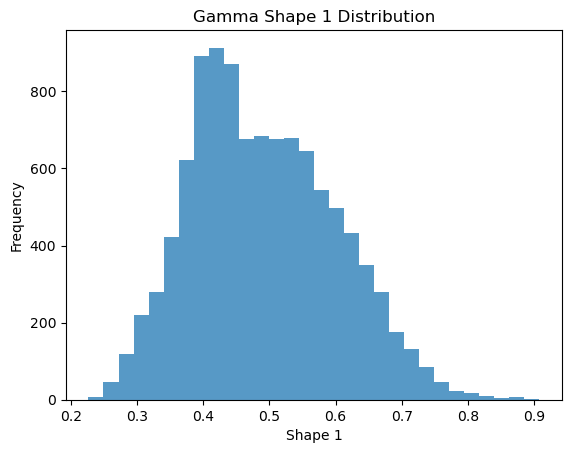

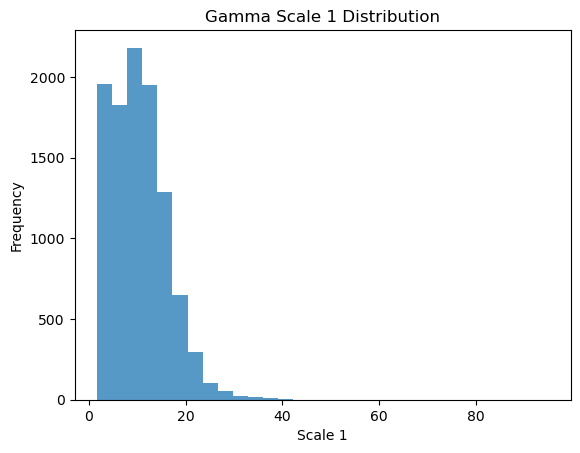

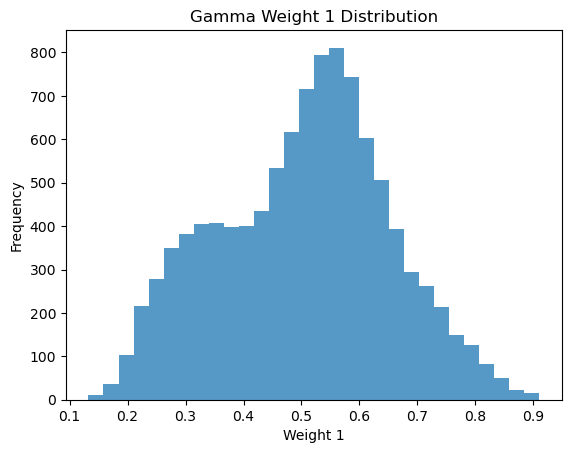

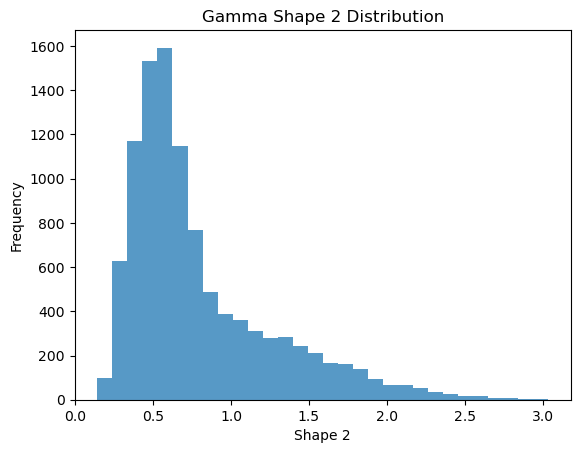

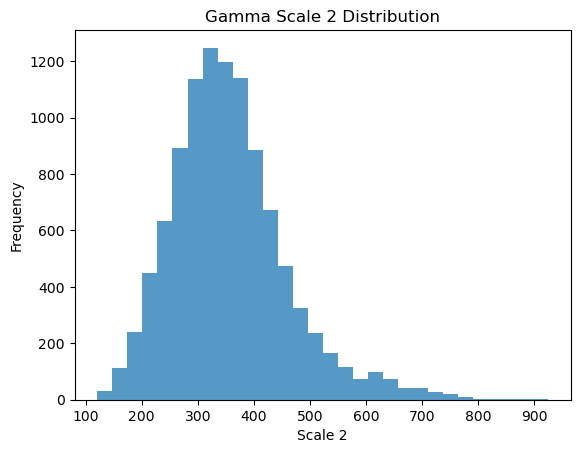

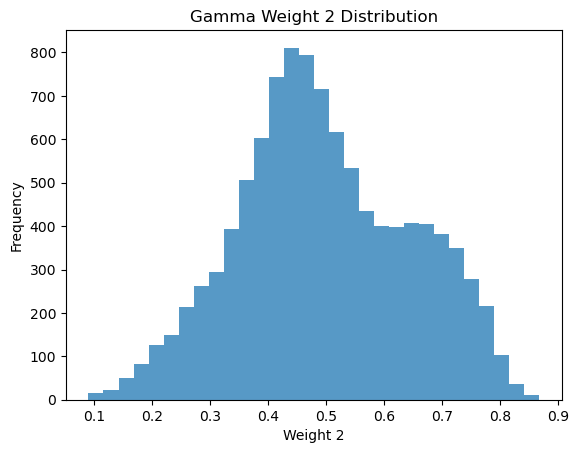

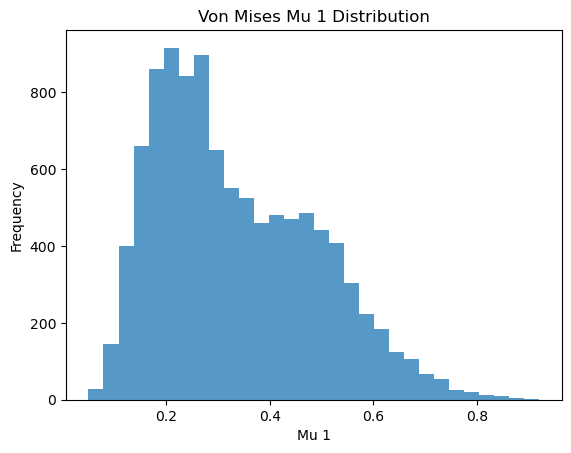

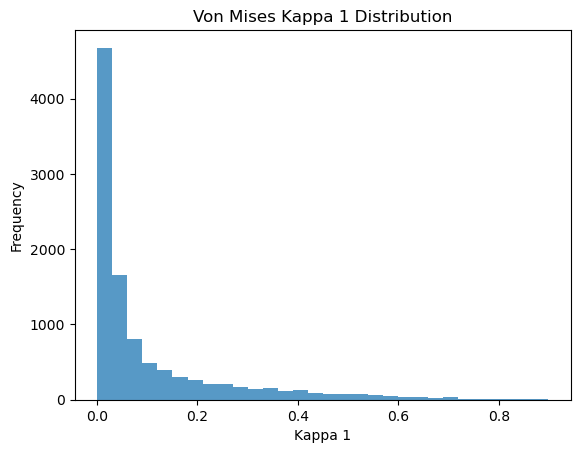

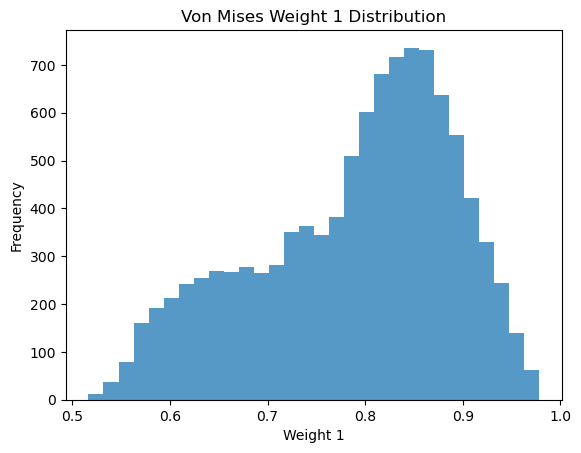

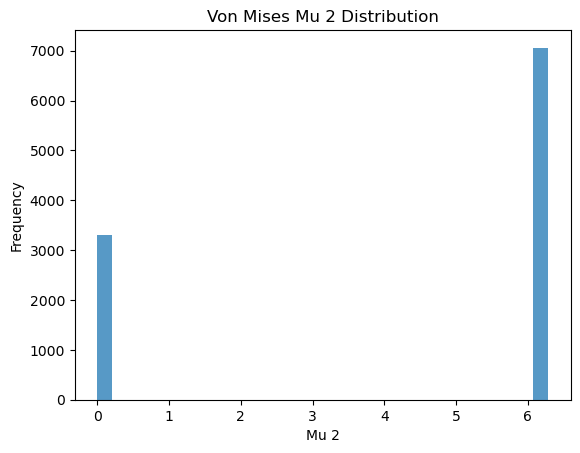

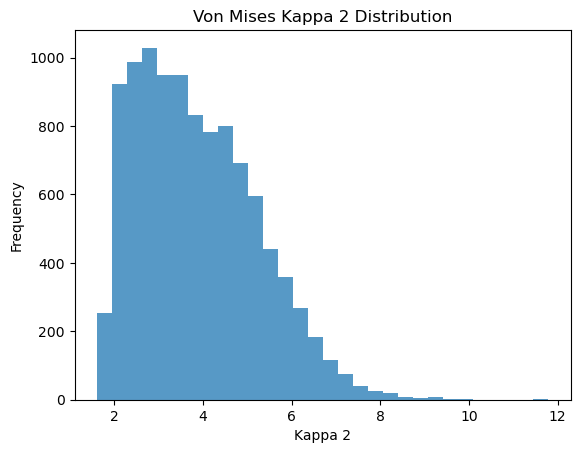

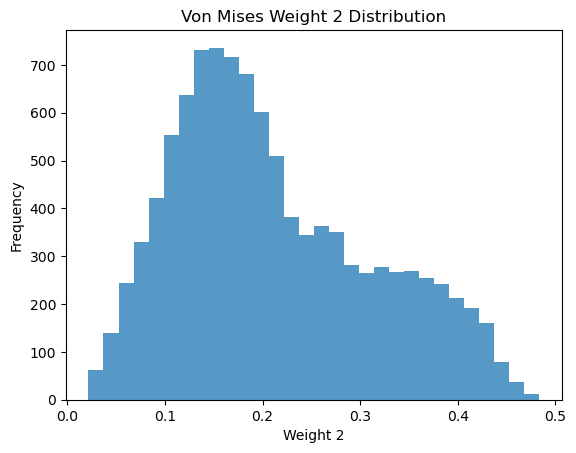

In [ ]:
# -----------------------------------------------------------
# Define a helper function to plot histograms
#    for the collected parameters
# -----------------------------------------------------------
def plot_histogram(data, title, xlabel):
    """
    Plots a histogram of the provided data.

    Args:
        data (list): Data points to plot in a histogram.
        title (str): Title of the histogram plot.
        xlabel (str): X-axis label.
    """
    plt.figure()
    plt.hist(data, bins=30, alpha=0.75)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel('Frequency')

    # Generate a filename from the title (replace spaces with underscores)
    filename = title.replace(' ', '_') + '.png'
    filepath = os.path.join(output_dir, filename)

    # Save the figure
    plt.savefig(filepath, dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()  # Close the figure to free memory\

# -----------------------------------------------------------
# Plot histograms for each parameter distribution
# -----------------------------------------------------------
plot_histogram(gamma_shape1_list, 'Gamma Shape 1 Distribution', 'Shape 1')
plot_histogram(gamma_scale1_list, 'Gamma Scale 1 Distribution', 'Scale 1')
plot_histogram(gamma_weight1_list, 'Gamma Weight 1 Distribution', 'Weight 1')
plot_histogram(gamma_shape2_list, 'Gamma Shape 2 Distribution', 'Shape 2')
plot_histogram(gamma_scale2_list, 'Gamma Scale 2 Distribution', 'Scale 2')
plot_histogram(gamma_weight2_list, 'Gamma Weight 2 Distribution', 'Weight 2')
plot_histogram(vonmises_mu1_list, 'Von Mises Mu 1 Distribution', 'Mu 1')
plot_histogram(vonmises_kappa1_list, 'Von Mises Kappa 1 Distribution', 'Kappa 1')
plot_histogram(vonmises_weight1_list, 'Von Mises Weight 1 Distribution', 'Weight 1')
plot_histogram(vonmises_mu2_list, 'Von Mises Mu 2 Distribution', 'Mu 2')
plot_histogram(vonmises_kappa2_list, 'Von Mises Kappa 2 Distribution', 'Kappa 2')
plot_histogram(vonmises_weight2_list, 'Von Mises Weight 2 Distribution', 'Weight 2')

# -----------------------------------------------------------
# Remove the hook to stop capturing outputs
#    in subsequent forward passes
# -----------------------------------------------------------
hook_handle.remove()

# Validate the predictions from the model

We want to assess how well the model is generating movement, habitat selection and next-step probabilities, so we will extract those probabilities at the location of each observed step.

## Importing spatial data

Instead of importing the stacks of local layers (one for each step), here we want to import the spatial covariates for the extent we want to simulate over. We use an extent that covers all of the observed locations, which refer to as the 'landscape'.

## NDVI

We have monthly NDVI layers for 2018 and 2019, which we import as a stack. The files don't import with a time component, so we will use a function further down that indexes them correctly.

In [ ]:
# for monthly NDVI
file_path = f'{base_path}/mapping/cropped rasters/ndvi_monthly.tif'

# read the raster file
with rasterio.open(file_path) as src:
    # Read the raster band as separate variable
    ndvi_landscape = src.read([i for i in range(1, src.count + 1)])
    # Get the metadata of the raster
    ndvi_meta = src.meta
    raster_transform = src.transform

    # Print the metadata to check for time component
    print("Metadata:", ndvi_meta)

    # Check for specific time-related metadata
    if 'TIFFTAG_DATETIME' in src.tags():
        print("Time component found:", src.tags()['TIFFTAG_DATETIME'])
    else:
        print("No explicit time component found in metadata.")

# the rasters don't contain a time component, so we will use a function later to index the layers correctly

Metadata: {'driver': 'GTiff', 'dtype': 'float32', 'nodata': nan, 'width': 2400, 'height': 2280, 'count': 24, 'crs': CRS.from_wkt('PROJCS["GDA94 / Geoscience Australia Lambert",GEOGCS["GDA94",DATUM["Geocentric_Datum_of_Australia_1994",SPHEROID["GRS 1980",6378137,298.257222101,AUTHORITY["EPSG","7019"]],AUTHORITY["EPSG","6283"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4283"]],PROJECTION["Lambert_Conformal_Conic_2SP"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",134],PARAMETER["standard_parallel_1",-18],PARAMETER["standard_parallel_2",-36],PARAMETER["false_easting",0],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","3112"]]'), 'transform': Affine(25.0, 0.0, 0.0,
       0.0, -25.0, -1406000.0)}
No explicit time component found in metadata.


### Prepare the NDVI data

There are a few things we need to do to prepare the landscape layers.

First, we need to ensure that there are no NA values in the data. For NDVI we will replace any NA values with -1 (which denotes water), as in our case that is typically why they were set to NA.

Secondly, the model expects the covariates to on *the same scale as the training data*. We will therefore scale the NDVI data using the same max and min scaling parameters as the training data. To get these, there are some min and max print statements in the `deepSSF_train.ipynb` script. When we plot the NDVI data below we will see that the values will no longer range from 0 to 1, which is because there are values in the landscape layers that are outside of the range of the training data.

NDVI metadata:
{'driver': 'GTiff', 'dtype': 'float32', 'nodata': nan, 'width': 2400, 'height': 2280, 'count': 24, 'crs': CRS.from_wkt('PROJCS["GDA94 / Geoscience Australia Lambert",GEOGCS["GDA94",DATUM["Geocentric_Datum_of_Australia_1994",SPHEROID["GRS 1980",6378137,298.257222101,AUTHORITY["EPSG","7019"]],AUTHORITY["EPSG","6283"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4283"]],PROJECTION["Lambert_Conformal_Conic_2SP"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",134],PARAMETER["standard_parallel_1",-18],PARAMETER["standard_parallel_2",-36],PARAMETER["false_easting",0],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","3112"]]'), 'transform': Affine(25.0, 0.0, 0.0,
       0.0, -25.0, -1406000.0)}


Affine transformation parameters:
| 25.00, 0.00, 0.00|
| 0.00,-25.00,-1406000.00|
| 0.00, 0.00, 1.00|


Shap

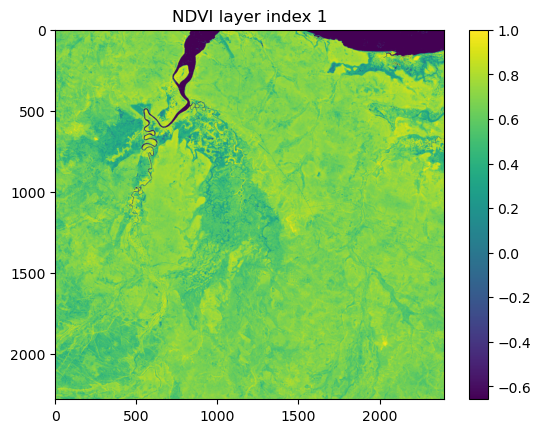

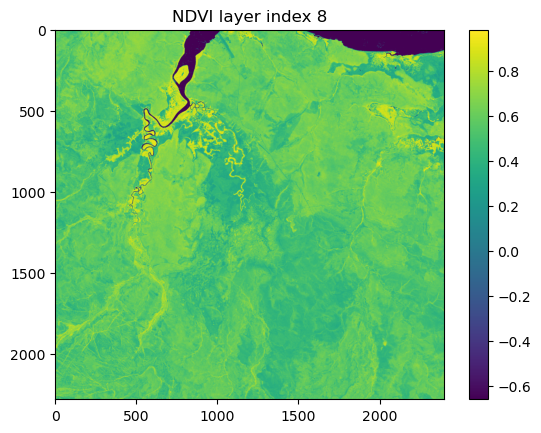

In [ ]:
# Check the coordinate reference system
print("NDVI metadata:")
print(ndvi_meta)
print("\n")

# Have a look at the affine transformation parameters that are used to convert pixel
# coordinates to geographic coordinates and vice versa
print("Affine transformation parameters:")
print(raster_transform)
print("\n")

# Check the shape (layers, row, columns) of the raster
print("Shape of the raster:")
print(ndvi_landscape.shape)

# Replace NaNs in the original array with -1, which represents water
ndvi_landscape = np.nan_to_num(ndvi_landscape, nan=-1.0)

# from the stack of local layers (training data)
ndvi_max = 0.8220
ndvi_min = -0.2772

# Convert the numpy array to a PyTorch tensor
ndvi_landscape_tens = torch.from_numpy(ndvi_landscape)

# Normalizing the data
ndvi_landscape_norm = (ndvi_landscape_tens - ndvi_min) / (ndvi_max - ndvi_min)

# Show two example layers of the scaled NDVI data
layer_index = 1
plt.imshow(ndvi_landscape_norm[layer_index,:,:].numpy())
plt.colorbar()
plt.title(f'NDVI layer index {layer_index}')
plt.show()

layer_index = 8
plt.imshow(ndvi_landscape_norm[layer_index,:,:].numpy())
plt.colorbar()
plt.title(f'NDVI layer index {layer_index}')
plt.show()

## Canopy cover

Canopy cover is just a single static layer.

In [ ]:
# Path to the canopy cover raster file
file_path = f'{base_path}/mapping/cropped rasters/canopy_cover.tif'

# read the raster file
with rasterio.open(file_path) as src:
    # Read the raster band as separate variable
    canopy_landscape = src.read(1)
    # Get the metadata of the raster
    canopy_meta = src.meta

### Prepare the canopy cover data

As with the NDVI data, we need to ensure that there are no NA values in the data.

As the canopy cover values in the landscape layer are within the same range as the training data, we see that the values range from 0 to 1.

Canopy metadata:
{'driver': 'GTiff', 'dtype': 'float32', 'nodata': -3.3999999521443642e+38, 'width': 2400, 'height': 2280, 'count': 1, 'crs': CRS.from_wkt('PROJCS["GDA94 / Geoscience Australia Lambert",GEOGCS["GDA94",DATUM["Geocentric_Datum_of_Australia_1994",SPHEROID["GRS 1980",6378137,298.257222101,AUTHORITY["EPSG","7019"]],AUTHORITY["EPSG","6283"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4283"]],PROJECTION["Lambert_Conformal_Conic_2SP"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",134],PARAMETER["standard_parallel_1",-18],PARAMETER["standard_parallel_2",-36],PARAMETER["false_easting",0],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","3112"]]'), 'transform': Affine(25.0, 0.0, 0.0,
       0.0, -25.0, -1406000.0)}


Shape of canopy raster:
(2280, 2400)


Number of NA values in the canopy raster:
0


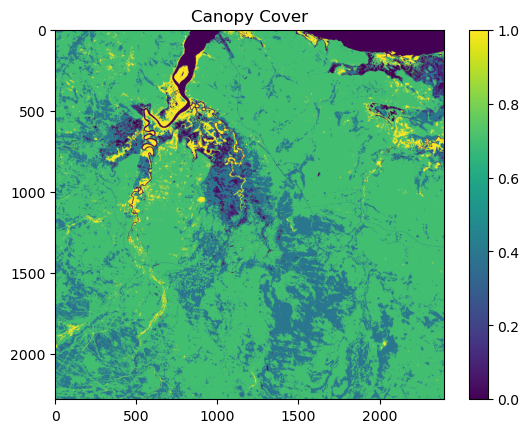

In [ ]:
# Check the canopy metadata:
print("Canopy metadata:")
print(canopy_meta)
print("\n")

# Check the shape (rows, columns) of the canopy raster:
print("Shape of canopy raster:")
print(canopy_landscape.shape)
print("\n")

# Check for NA values in the canopy raster:
print("Number of NA values in the canopy raster:")
print(np.isnan(canopy_landscape).sum())

# Define the maximum and minimum canopy values from the stack of local layers:
canopy_max = 82.5000
canopy_min = 0.0

# Convert the canopy data from a NumPy array to a PyTorch tensor:
canopy_landscape_tens = torch.from_numpy(canopy_landscape)

# Normalise the canopy data:
canopy_landscape_norm = (canopy_landscape_tens - canopy_min) / (canopy_max - canopy_min)

# Visualise the normalised canopy cover:
plt.imshow(canopy_landscape_norm.numpy())
plt.colorbar()
plt.title('Canopy Cover')
plt.show()


## Herbaceous vegetation

In [ ]:
# Path to the herbaceous vegetation raster file
file_path = f'{base_path}/mapping/cropped rasters/veg_herby.tif'

# read the raster file
with rasterio.open(file_path) as src:
    # Read the raster band as separate variable
    herby_landscape = src.read(1)
    # Get the metadata of the raster
    herby_meta = src.meta

Herbaceous metadata:
{'driver': 'GTiff', 'dtype': 'float32', 'nodata': -3.3999999521443642e+38, 'width': 2400, 'height': 2280, 'count': 1, 'crs': CRS.from_wkt('PROJCS["GDA94 / Geoscience Australia Lambert",GEOGCS["GDA94",DATUM["Geocentric_Datum_of_Australia_1994",SPHEROID["GRS 1980",6378137,298.257222101,AUTHORITY["EPSG","7019"]],AUTHORITY["EPSG","6283"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4283"]],PROJECTION["Lambert_Conformal_Conic_2SP"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",134],PARAMETER["standard_parallel_1",-18],PARAMETER["standard_parallel_2",-36],PARAMETER["false_easting",0],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","3112"]]'), 'transform': Affine(25.0, 0.0, 0.0,
       0.0, -25.0, -1406000.0)}


Shape of herbaceous raster:
(2280, 2400)


Number of NA values in the herbaceous ve

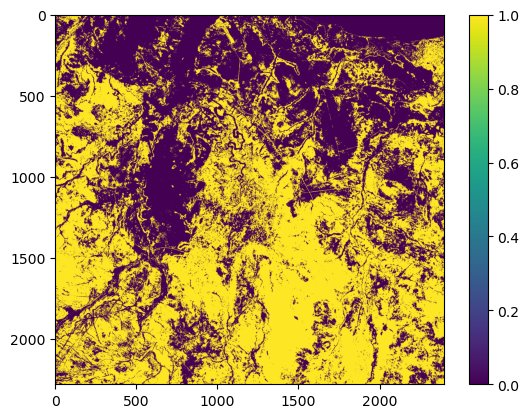

In [ ]:
# Check the herbaceous metadata:
print("Herbaceous metadata:")
print(herby_meta)
print("\n")

# Check the shape (rows, columns) of the herbaceous raster:
print("Shape of herbaceous raster:")
print(herby_landscape.shape)
print("\n")

# Check for NA values in the herby raster:
print("Number of NA values in the herbaceous vegetation raster:")
print(np.isnan(herby_landscape).sum())

# Define the maximum and minimum herbaceous values from the stack of local layers:
herby_max = 1.0
herby_min = 0.0

# Convert the herbaceous data from a NumPy array to a PyTorch tensor:
herby_landscape_tens = torch.from_numpy(herby_landscape)

# Normalize the herbaceous data:
herby_landscape_norm = (herby_landscape_tens - herby_min) / (herby_max - herby_min)

# Visualize the normalised herbaceous cover:
plt.imshow(herby_landscape_norm.numpy())
plt.colorbar()
plt.show()


## Slope

In [ ]:
# Path to the slope raster file
file_path = f'{base_path}/mapping/cropped rasters/slope.tif'

# read the raster file
with rasterio.open(file_path) as src:
    # Read the raster band as separate variable
    slope_landscape = src.read(1)
    # Get the metadata of the raster
    slope_meta = src.meta

Slope metadata:
{'driver': 'GTiff', 'dtype': 'float32', 'nodata': nan, 'width': 2400, 'height': 2280, 'count': 1, 'crs': CRS.from_wkt('PROJCS["GDA94 / Geoscience Australia Lambert",GEOGCS["GDA94",DATUM["Geocentric_Datum_of_Australia_1994",SPHEROID["GRS 1980",6378137,298.257222101,AUTHORITY["EPSG","7019"]],AUTHORITY["EPSG","6283"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4283"]],PROJECTION["Lambert_Conformal_Conic_2SP"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",134],PARAMETER["standard_parallel_1",-18],PARAMETER["standard_parallel_2",-36],PARAMETER["false_easting",0],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","3112"]]'), 'transform': Affine(25.0, 0.0, 0.0,
       0.0, -25.0, -1406000.0)}


Shape of slope landscape raster:
(2280, 2400)


Number of NA values in the slope raster:
9356


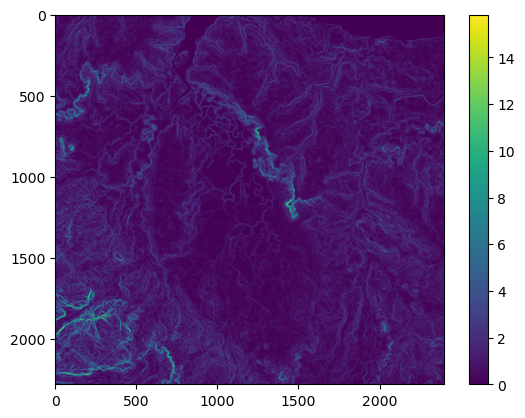

In [ ]:
# Check the slope metadata:
print("Slope metadata:")
print(slope_meta)
print("\n")

# Check the shape (rows, columns) of the slope landscape raster:
print("Shape of slope landscape raster:")
print(slope_landscape.shape)
print("\n")

# Check for NA values in the slope raster:
print("Number of NA values in the slope raster:")
print(np.isnan(slope_landscape).sum())

# Replace NaNs in the slope array with 0.0:
slope_landscape = np.nan_to_num(slope_landscape, nan=0.0)

# Define the maximum and minimum slope values from the stack of local layers:
slope_max = 12.2981
slope_min = 0.0006

# Convert the slope landscape data from a NumPy array to a PyTorch tensor:
slope_landscape_tens = torch.from_numpy(slope_landscape)

# Normalize the slope landscape data:
slope_landscape_norm = (slope_landscape_tens - slope_min) / (slope_max - slope_min)

# Visualize the slope landscape (note: displaying the original tensor, not the normalised data):
plt.imshow(slope_landscape_tens.numpy())
plt.colorbar()
plt.show()


# Subset function (with padding)

Now that we have our landscape layers imported, we need a way to crop out the local layers that can be fed into the deepSSF model as covariates.

We will use the same subset function as in the simulation script, which we stored in the `deepSSF_utils.py` script. This function will take the landscape layers and a set of coordinates, and return the local layers for those coordinates.

This function also has padding for if the simulated individual was to go off the edge of the landscape, which we retain here (although we won't need that functionality).

In [ ]:
subset_raster = deepSSF_utils.subset_raster_with_padding_torch

### Testing the subset function

Use the subset function to crop out the local layers for all covariates. Try different locations using the x and y coordinates, which are in geographic coordinates (x = easting/longitude, y = northing/latitude).

In [ ]:
buffalo_id = 2005
# in our case the actual dataset will be slightly smaller due to steps being removed that were outside the extent
n_samples = 10297

# Specify the path to CSV file
# csv_file_path = f'{base_path}/buffalo_local_data_id/buffalo_{buffalo_id}_data_df_lag_1hr_n{n_samples}.csv'
csv_file_path = f'{base_path}/buffalo_local_data_id/buffalo_temporal_cont_{buffalo_id}_data_df_lag_1hr_n{n_samples}.csv'

# Read the CSV file into a DataFrame
buffalo_df = pd.read_csv(csv_file_path)
print(buffalo_df.shape)

# Lag the values in column 'A' by one index to get the bearing of the previous step
buffalo_df['bearing_tm1'] = buffalo_df['bearing'].shift(1)
# Pad the missing value with a specified value, e.g., 0
buffalo_df['bearing_tm1'] = buffalo_df['bearing_tm1'].fillna(0)

# Display the first few rows of the DataFrame
buffalo_df

(10103, 43)


,x_,y_,t_,id,x1_,y1_,x2_,y2_,x2_cent,y2_cent,...,bearing,bearing_sin,bearing_cos,ta,cos_ta,x_min,x_max,y_min,y_max,bearing_tm1
0,41969.310875,-1.435671e+06,2018-07-25T01:04:23Z,2005,41969.310875,-1.435671e+06,41921.521939,-1.435654e+06,-47.788936,16.857110,...,2.802478,0.332652,-0.943050,1.367942,0.201466,40706.810875,43231.810875,-1.436934e+06,-1.434409e+06,0.000000
1,41921.521939,-1.435654e+06,2018-07-25T02:04:39Z,2005,41921.521939,-1.435654e+06,41779.439594,-1.435601e+06,-142.082345,53.568427,...,2.781049,0.352783,-0.935705,-0.021429,0.999770,40659.021939,43184.021939,-1.436917e+06,-1.434392e+06,2.802478
2,41779.439594,-1.435601e+06,2018-07-25T03:04:17Z,2005,41779.439594,-1.435601e+06,41841.203272,-1.435635e+06,61.763677,-34.322938,...,-0.507220,-0.485749,0.874098,2.994917,-0.989262,40516.939594,43041.939594,-1.436863e+06,-1.434338e+06,2.781049
3,41841.203272,-1.435635e+06,2018-07-25T04:04:39Z,2005,41841.203272,-1.435635e+06,41655.463332,-1.435604e+06,-185.739939,31.003534,...,2.976198,0.164641,-0.986354,-2.799767,-0.942144,40578.703272,43103.703272,-1.436898e+06,-1.434373e+06,-0.507220
4,41655.463332,-1.435604e+06,2018-07-25T05:04:27Z,2005,41655.463332,-1.435604e+06,41618.651923,-1.435608e+06,-36.811409,-4.438037,...,-3.021610,-0.119695,-0.992811,0.285377,0.959556,40392.963332,42917.963332,-1.436867e+06,-1.434342e+06,2.976198
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10098,42188.462885,-1.436637e+06,2019-10-31T16:55:30Z,2005,42188.462885,-1.436637e+06,42183.410380,-1.436642e+06,-5.052505,-4.882310,...,-2.373324,-0.694891,-0.719115,0.241847,0.970897,40925.962885,43450.962885,-1.437900e+06,-1.435375e+06,-2.615171
10099,42183.410380,-1.436642e+06,2019-10-31T17:54:32Z,2005,42183.410380,-1.436642e+06,42190.117488,-1.436641e+06,6.707107,1.627287,...,0.238022,0.235781,0.971806,2.611346,-0.862682,40920.910380,43445.910380,-1.437905e+06,-1.435380e+06,-2.373324
10100,42190.117488,-1.436641e+06,2019-10-31T18:55:36Z,2005,42190.117488,-1.436641e+06,42195.941372,-1.436634e+06,5.823885,6.775817,...,0.860807,0.758369,0.651826,0.622785,0.812257,40927.617488,43452.617488,-1.437903e+06,-1.435378e+06,0.238022
10101,42195.941372,-1.436634e+06,2019-10-31T19:55:03Z,2005,42195.941372,-1.436634e+06,42189.368382,-1.436888e+06,-6.572990,-254.371767,...,-1.596631,-0.999666,-0.025831,-2.457438,-0.774953,40933.441372,43458.441372,-1.437896e+06,-1.435371e+06,0.860807


Text(0.5, 1.0, 'Slope Subset')

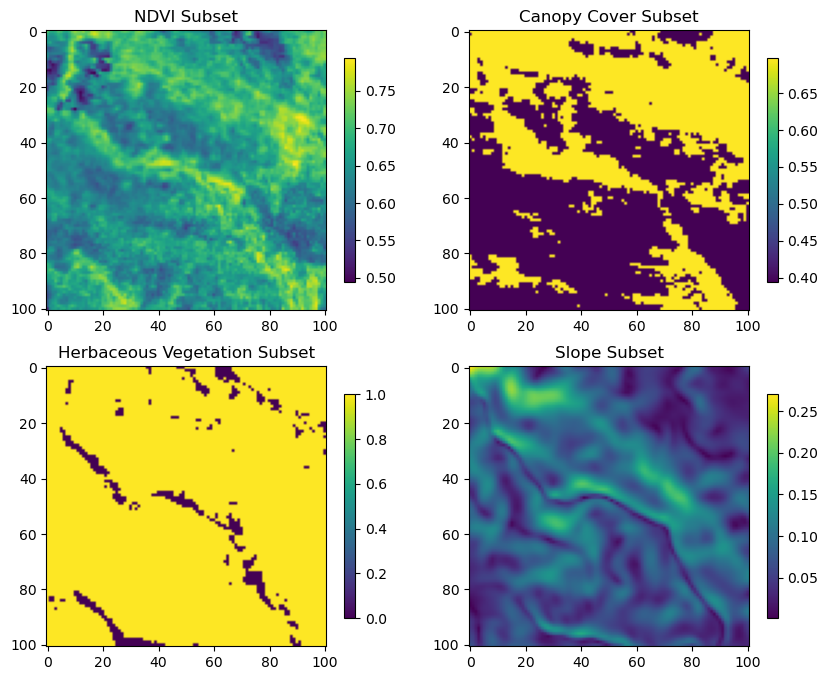

In [ ]:
# Pick a location (x, y) from the buffalo DataFrame
x = buffalo_df['x1_'].iloc[0]
y = buffalo_df['y1_'].iloc[0]

# Define the size of the window to extract
window_size = 101

# Select the NDVI layer index
which_ndvi = 1

# Extract subsets from various raster layers using the custom function.
# Each call centres the window at the specified (x, y) location and applies padding where necessary.
ndvi_subset, origin_x, origin_y = subset_raster(ndvi_landscape_norm[which_ndvi, :, :],
                                                x, y, window_size, raster_transform)
canopy_subset, origin_x, origin_y = subset_raster(canopy_landscape_norm,
                                                  x, y, window_size, raster_transform)
herby_subset, origin_x, origin_y = subset_raster(herby_landscape_norm,
                                                 x, y, window_size, raster_transform)
slope_subset, origin_x, origin_y = subset_raster(slope_landscape_norm,
                                                 x, y, window_size, raster_transform)

# Create a 2x2 grid of subplots with a fixed figure size.
fig, axs = plt.subplots(2, 2, figsize=(10, 8))

# Plot the NDVI subset.
im0 = axs[0, 0].imshow(ndvi_subset.numpy(), cmap='viridis')
fig.colorbar(im0, ax=axs[0, 0], shrink=0.8)
axs[0, 0].set_title('NDVI Subset')

# Plot the Canopy Cover subset.
im1 = axs[0, 1].imshow(canopy_subset.numpy(), cmap='viridis')
fig.colorbar(im1, ax=axs[0, 1], shrink=0.8)
axs[0, 1].set_title('Canopy Cover Subset')

# Plot the Herbaceous Vegetation subset.
im2 = axs[1, 0].imshow(herby_subset.numpy(), cmap='viridis')
fig.colorbar(im2, ax=axs[1, 0], shrink=0.8)
axs[1, 0].set_title('Herbaceous Vegetation Subset')

# Plot the Slope subset.
im3 = axs[1, 1].imshow(slope_subset.numpy(), cmap='viridis')
fig.colorbar(im3, ax=axs[1, 1], shrink=0.8)
axs[1, 1].set_title('Slope Subset')

## Create a mask for edge cells

Due to the padding at the edges of the covariates, convolutional layers create artifacts that can affect the colour scale of the predictions when plotting. To avoid this, we will create a mask that we can apply to the predictions to remove the edge cells.

In [ ]:
# Create a mask to remove the edge values for plotting
# (as it affects the colour scale)
x_mask = np.ones_like(ndvi_subset)
y_mask = np.ones_like(ndvi_subset)

# Mask out bordering cells
x_mask[:, :3] = -np.inf
x_mask[:, 98:] = -np.inf
y_mask[:3, :] = -np.inf
y_mask[98:, :] = -np.inf

# Setup simulation parameters

To get the simulation running we need a few extra functions.

Firstly, we need to index the NDVI layers correctly, based on the time of the simulated location. We'll do this by creating a function that takes day of the year of the simulated location and returns the correct index for the NDVI layers.

Recall that Python indexes from 0, so when the month_index is equal to 2 for instance, this will index the third layer, which is for March.

In [ ]:
# Create a mapping from day of the year to month index
def day_to_month_index(day_of_year):
    # Calculate the year and the day within that year
    base_date = datetime(2018, 1, 1) # base date for the calculation, which is when the NDVI layers start
    date = base_date + timedelta(days=int(day_of_year) - 1)
    year_diff = date.year - base_date.year
    month_index = (date.month - 1) + (year_diff * 12)  # month index (0-based, accounting for year change)
    return month_index

yday = 70 # day of the year, which is March 11th
month_index = day_to_month_index(yday)
print(month_index)

2


# Next-step probability values

We can now calculate the next-step probabilities for each observed step. As we generate habitat selection, movement and next-step probability surfaces, we can get the predicted probability values for each one, which can be compared to the respective process in the SSF.

The process for generating the next-step probabilities is as follows:

1. Get the current location of the individual
2. Crop out the local layers for the current location
3. Run the model of the local layers to get the habitat selection, movement and next-step probability surfaces
4. Get the predicted probability values at the location of the next step
5. Store the predicted probability values and export them as a csv for comparison with the SSF

First, select the data to generate prediction values for. For testing the function we can select a subset.

In [ ]:
# To select a subset of samples to test the function
# test_data = buffalo_df.iloc[0:10]

# To select all of the data
test_data = buffalo_df

# Get the number of samples in the test data
n_samples = len(test_data)
print(f'Number of samples: {n_samples}')

# Create empty vectors to store the predicted probabilities
habitat_probs = np.repeat(0., n_samples)
move_probs = np.repeat(0., n_samples)
next_step_probs = np.repeat(0., n_samples)


Number of samples: 10103


## Loop over each step

In [ ]:
# Create directory for saving prediction images
os.makedirs(f'{output_dir}/prediction_images', exist_ok=True)

# Start at 1 so the bearing at t - 1 is available
for i in range(1, n_samples):
# for i in range(1, 4):

  sample = test_data.iloc[i]

  # Current location (x1, y1)
  x = sample['x1_']
  y = sample['y1_']

  # Convert geographic coordinates to pixel coordinates
  px, py = ~raster_transform * (x, y)
  # print('px and py are ', px, py) # Debugging

  # Next step location (x2, y2)
  x2 = sample['x2_']
  y2 = sample['y2_']

  # Convert geographic coordinates to pixel coordinates
  px2, py2 = ~raster_transform * (x2, y2)
  # print('px2 and py2 are ', px2, py2) # Debugging

  # The difference in x and y coordinates
  d_x = x2 - x
  d_y = y2 - y
  # print('d_x and d_y are ', d_x, d_y) # Debugging

  # The difference in pixel coordinates
  d_px = px2 - px
  d_py = py2 - py
  # print('d_px and d_py are ', d_px, d_py) # Debugging

  # Temporal covariates
  # hour_t2_sin = sample['hour_t2_sin']
  # hour_t2_cos = sample['hour_t2_cos']
  # yday_t2_sin = sample['yday_t2_sin']
  # yday_t2_cos = sample['yday_t2_cos']

  # Temporal covariates for t1
  hour_t1_sin1 = sample['hour_t1_sin1']
  hour_t1_cos1 = sample['hour_t1_cos1']
  # hour_t1_sin2 = sample['hour_t1_sin2']
  # hour_t1_cos2 = sample['hour_t1_cos2']
  yday_t1_sin1 = sample['yday_t1_sin1']
  yday_t1_cos1 = sample['yday_t1_cos1']
  # yday_t1_sin2 = sample['yday_t1_sin2']
  # yday_t1_cos2 = sample['yday_t1_cos2']

  # Bearing of previous step (t - 1)
  bearing = sample['bearing_tm1']

  # Hour of the day (for saving the plot)
  hour_t2 = sample['hour_t2']

  # Day of the year
  yday = sample['yday_t2']

  # Convert day of the year to month index
  month_index = day_to_month_index(yday)
  # print(month_index)

  # Extract the subset of the covariates at the location of x1, y1
  # NDVI
  ndvi_subset, origin_x, origin_y = subset_raster(ndvi_landscape_norm[month_index,:,:],
                                                  x, y,
                                                  window_size,
                                                  raster_transform)

  # Canopy cover
  canopy_subset, origin_x, origin_y = subset_raster(canopy_landscape_norm,
                                                    x, y,
                                                    window_size,
                                                    raster_transform)

  # Herbaceous vegetation
  herby_subset, origin_x, origin_y = subset_raster(herby_landscape_norm,
                                                   x, y,
                                                   window_size,
                                                   raster_transform)

  # Slope
  slope_subset, origin_x, origin_y = subset_raster(slope_landscape_norm,
                                                   x, y,
                                                   window_size,
                                                   raster_transform)

  # Location of the current step in local pixel coordinates
  px_subset = px - origin_x
  py_subset = py - origin_y
  # print('px_subset and py_subset are ', px_subset, py_subset) # Debugging

  # Location of the next step in local pixel coordinates
  px2_subset = px2 - origin_x
  py2_subset = py2 - origin_y
  # print('px2_subset and py2_subset are ', px2_subset, py2_subset, '\n') # Debugging

  # print(int(py2_subset), int(px2_subset))

  # Location of the next step in local pixel coordinates
  px2_subset_corrected = (px2 - px) + (px - origin_x)
  py2_subset_corrected = (py2 - py) + (py - origin_y)
  # print('px2_subset_corrected and py2_subset_corrected are ', px2_subset_corrected, py2_subset_corrected, '\n') # Debugging

  # Extract the value of the covariates at the location of x2, y2
  # value = ndvi_subset.detach().cpu().numpy()[(int(py2_subset), int(px2_subset))]

  # Stack the channels along a new axis
  x1 = torch.stack([ndvi_subset, canopy_subset, herby_subset, slope_subset], dim=0)

  # Add a batch dimension (required to be the correct dimension for the model)
  x1 = x1.unsqueeze(0).to(device)
  # print(x1.shape)

  # Convert lists to PyTorch tensors
  # hour_t2_sin_tensor = torch.tensor(hour_t2_sin).float()
  # hour_t2_cos_tensor = torch.tensor(hour_t2_cos).float()
  # yday_t2_sin_tensor = torch.tensor(yday_t2_sin).float()
  # yday_t2_cos_tensor = torch.tensor(yday_t2_cos).float()

  # Temporal covariates for t1
  hour_t1_sin1_tensor = torch.tensor(hour_t1_sin1).float()
  hour_t1_cos1_tensor = torch.tensor(hour_t1_cos1).float()
  # hour_t1_sin2_tensor = torch.tensor(hour_t1_sin2).float()
  # hour_t1_cos2_tensor = torch.tensor(hour_t1_cos2).float()
  yday_t1_sin1_tensor = torch.tensor(yday_t1_sin1).float()
  yday_t1_cos1_tensor = torch.tensor(yday_t1_cos1).float()
  # yday_t1_sin2_tensor = torch.tensor(yday_t1_sin2).float()
  # yday_t1_cos2_tensor = torch.tensor(yday_t1_cos2).float()

  # Stack tensors
  # x2 = torch.stack((hour_t2_sin_tensor.unsqueeze(0),
  #                   hour_t2_cos_tensor.unsqueeze(0),
  #                   yday_t2_sin_tensor.unsqueeze(0),
  #                   yday_t2_cos_tensor.unsqueeze(0)),
  #                   dim=1)

  # Stack tensors
  x2 = torch.stack((hour_t1_sin1_tensor.unsqueeze(0),
                    hour_t1_cos1_tensor.unsqueeze(0),
                    # hour_t1_sin2_tensor.unsqueeze(0),
                    # hour_t1_cos2_tensor.unsqueeze(0),
                    yday_t1_sin1_tensor.unsqueeze(0),
                    yday_t1_cos1_tensor.unsqueeze(0)
                    # yday_t1_sin2_tensor.unsqueeze(0),
                    # yday_t1_cos2_tensor.unsqueeze(0)
                    ),
                    dim=1)

  # print(x2)
  # print(x2.shape)
  x2 = x2.to(device)

  # Put bearing in the correct dimension (batch_size, 1)
  bearing = torch.tensor(bearing).float().unsqueeze(0).unsqueeze(0)
  # print(bearing)
  # print(bearing.shape)
  bearing = bearing.to(device)


  # -------------------------------------------------------------------------
  # Run the model
  # -------------------------------------------------------------------------
  model_output = model((x1, x2, bearing))


  # -------------------------------------------------------------------------
  # Habitat selection probability
  # -------------------------------------------------------------------------
  hab_density = model_output.detach().cpu().numpy()[0,:,:,0]
  hab_density_exp = np.exp(hab_density)

  # Normalise the probability surface to sum to 1
  hab_density_exp_norm = hab_density_exp / np.sum(hab_density_exp)
  # print(np.sum(hab_density_exp_norm))  # Should be 1

  # Store the probability of habitat selection at the location of x2, y2
  # These probabilities are normalised in the model function
  habitat_probs[i] = hab_density_exp_norm[(int(py2_subset), int(px2_subset))]
  # print('Habitat probability value = ', habitat_probs[i])


  # -------------------------------------------------------------------------
  # Movement probability
  # -------------------------------------------------------------------------
  move_density = model_output.detach().cpu().numpy()[0,:,:,1]
  move_density_exp = np.exp(move_density)

  # Normalise the probability surface to sum to 1
  move_density_exp_norm = move_density_exp / np.sum(move_density_exp)
  # print(np.sum(move_density_exp_norm))  # Should be 1

  # Store the movement probability at the location of x2, y2
  # These probabilities are normalised in the model function
  move_probs[i] = move_density_exp_norm[(int(py2_subset), int(px2_subset))]
  # print('Movement probability value = ', move_probs[i])


  # -------------------------------------------------------------------------
  # Next step probability
  # -------------------------------------------------------------------------
  step_density = hab_density + move_density
  step_density_exp = np.exp(step_density)
  # print('Sum of step density exp = ', np.sum(step_density_exp)) # Won't be 1

  step_density_exp_norm = step_density_exp / np.sum(step_density_exp)
  # print('Sum of step density exp norm = ', np.sum(step_density_exp_norm)) # Should be 1

  # Extract the value of the covariates at the location of x2, y2
  next_step_probs[i] = step_density_exp_norm[(int(py2_subset), int(px2_subset))]
  # print('Next-step probability value = ', next_step_probs[i])


  # -------------------------------------------------------------------------
  # Plot the next-step predictions
  # -------------------------------------------------------------------------

  # Plot the first few probability surfaces - change the condition to i < n_steps to plot all
  if i < 51:

    # Mask out bordering cells
    hab_density_mask = np.log(hab_density_exp_norm) * x_mask * y_mask
    move_density_mask = np.log(move_density_exp_norm) * x_mask * y_mask
    step_density_mask = np.log(step_density_exp_norm) * x_mask * y_mask

    # Create a mask for the next step
    next_step_mask = np.ones_like(hab_density)
    next_step_mask[int(py2_subset), int(px2_subset)] = -np.inf

    # Plot the outputs
    fig_out, axs_out = plt.subplots(2, 2, figsize=(10, 8))

    # Plot NDVI
    im1 = axs_out[0, 0].imshow(ndvi_subset.numpy(), cmap='viridis')
    axs_out[0, 0].set_title('NDVI')
    fig_out.colorbar(im1, ax=axs_out[0, 0], shrink=0.7)

    # Plot habitat selection log-probability
    im2 = axs_out[0, 1].imshow(hab_density_mask * next_step_mask, cmap='viridis')
    axs_out[0, 1].set_title('Habitat selection log-probability')
    fig_out.colorbar(im2, ax=axs_out[0, 1], shrink=0.7)

    # Movement density log-probability
    im3 = axs_out[1, 0].imshow(move_density_mask * next_step_mask, cmap='viridis')
    axs_out[1, 0].set_title('Movement log-probability')
    fig_out.colorbar(im3, ax=axs_out[1, 0], shrink=0.7)

    # Next-step probability
    im4 = axs_out[1, 1].imshow(step_density_mask * next_step_mask, cmap='viridis')
    axs_out[1, 1].set_title('Next-step log-probability')
    fig_out.colorbar(im4, ax=axs_out[1, 1], shrink=0.7)

    filename_covs = f'{output_dir}/prediction_images/id{buffalo_id}_step_index{i+1}_yday{yday}_hour{hour_t2}.png'
    plt.tight_layout()
    plt.savefig(filename_covs, dpi=150)
    # plt.show()
    plt.close()  # Close the figure to free memory


In [ ]:
print(next_step_probs)

[0.00000000e+00 1.63264817e-03 3.04191676e-03 ... 6.52288318e-01
 2.49395351e-04 6.12699310e-04]


### Make a GIF of the prediction images

Here's a function to call to make a gif from a given directory.

In [ ]:
# Path to your images
image_folder =  f'{output_dir}/prediction_images'
# Output GIF filename
output_filename = f'{output_dir}/prediction_gif_id{buffalo_id}_yday{yday_t2_integer}_hour{hour_t2_integer}_bearing{bearing_degrees}.gif'
# Create the GIF
create_gif(image_folder, output_filename, fps=5)

## Calculate the null probabilities

As each cell has a probability values, we can calculate what the probability would be if the model provided no information at all, and each cell was equally likely to be the next step. This is just 1 divided by the total number of cells.

In [ ]:
null_prob = 1 / (window_size ** 2)
print(f'Null probability: {null_prob:.3e}')

Null probability: 9.803e-05


## Compute the rolling average of the probabilities

In [ ]:
rolling_window_size = 100 # Rolling window size

# Convert to pandas Series and compute rolling mean
rolling_mean_habitat = pd.Series(habitat_probs).rolling(window=window_size, center=True).mean()
rolling_mean_movement = pd.Series(move_probs).rolling(window=window_size, center=True).mean()
rolling_mean_next_step = pd.Series(next_step_probs).rolling(window=window_size, center=True).mean()

# Plot the probabilities

We can get an idea of how variable the probabilities are for the habitat selection and movement surfaces, and for the next-step probabilities, by plotting them across the trajectory

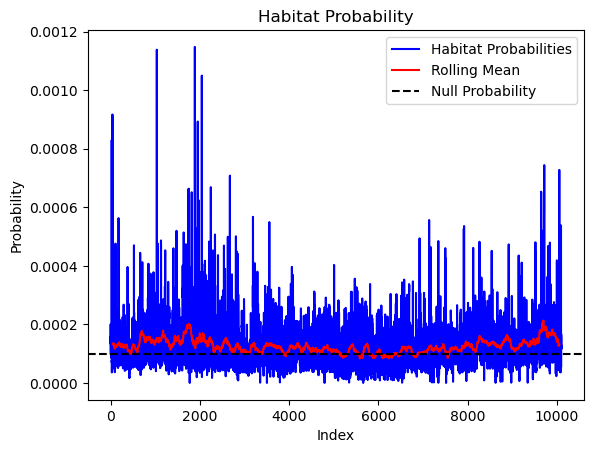

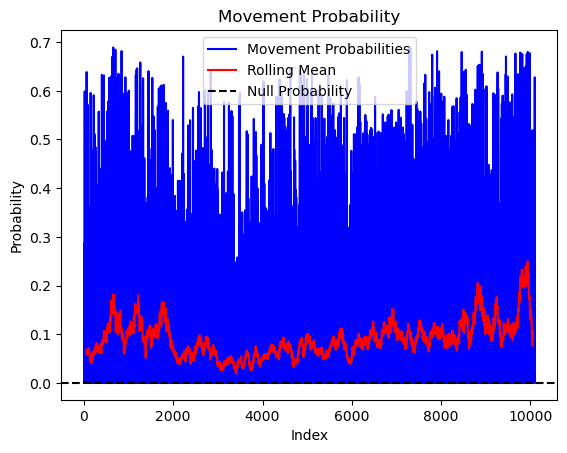

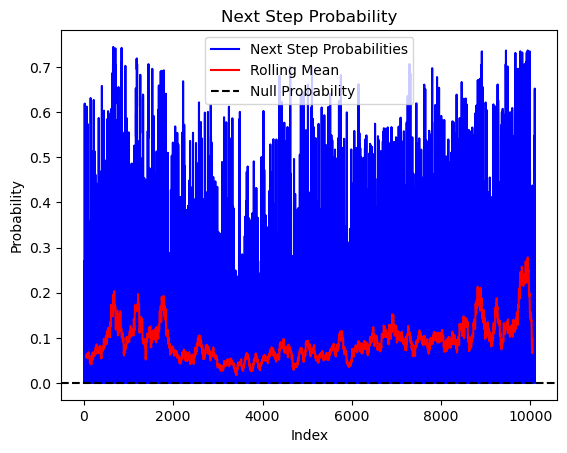

In [ ]:
# Plot the habitat probs through time as a line graph
plt.plot(habitat_probs[habitat_probs > 0], color='blue', label='Habitat Probabilities')
plt.plot(rolling_mean_habitat[rolling_mean_habitat > 0], color='red', label='Rolling Mean')
plt.axhline(y=null_prob, color='black', linestyle='--', label='Null Probability')  # null probs
plt.xlabel('Index')
plt.ylabel('Probability')
plt.title('Habitat Probability')
plt.legend()  # Add legend to differentiate lines
plt.savefig(f'{output_dir}/id{buffalo_id}_habitat_probs.png', dpi=300, bbox_inches='tight')
plt.show()

# Plot the movement probs through time as a line graph
plt.plot(move_probs[move_probs > 0], color='blue', label='Movement Probabilities')
plt.plot(rolling_mean_movement[rolling_mean_movement > 0], color='red', label='Rolling Mean')
plt.axhline(y=null_prob, color='black', linestyle='--', label='Null Probability')  # null probs
plt.xlabel('Index')
plt.ylabel('Probability')
plt.title('Movement Probability')
plt.legend()  # Add legend to differentiate lines
plt.savefig(f'{output_dir}/id{buffalo_id}_movement_probs.png', dpi=300, bbox_inches='tight')
plt.show()

# Plot the next step probs through time as a line graph
plt.plot(next_step_probs[next_step_probs > 0], color='blue', label='Next Step Probabilities')
plt.plot(rolling_mean_next_step[rolling_mean_next_step > 0], color='red', label='Rolling Mean')
plt.axhline(y=null_prob, color='black', linestyle='--', label='Null Probability')  # null probs
plt.xlabel('Index')
plt.ylabel('Probability')
plt.title('Next Step Probability')
plt.legend()  # Add legend to differentiate lines
plt.savefig(f'{output_dir}/id{buffalo_id}_next_step_probs.png', dpi=300, bbox_inches='tight')
plt.show()

# Save the probabilities

We can save the probabilities to a csv file to compare with the SSF probabilities.

In [ ]:
# Append the probabilities to the dataframe
buffalo_df['habitat_probs'] = habitat_probs
buffalo_df['move_probs'] = move_probs
buffalo_df['next_step_probs'] = next_step_probs

csv_filename = f'{output_dir}/deepSSF_id{buffalo_id}_n{len(test_data)}.csv'
print(csv_filename)
buffalo_df.to_csv(csv_filename, index=True)

../Python/outputs/model_training/djelk_derived_covs_CNN_move_7_2025-05-20/deepSSF_id2005_n10103.csv
